In [21]:
import numpy as np
import glob
import torch
import matplotlib.pyplot as plt
import random
from Utils import *
import os

In [22]:
# ----------------------------------
# Read filenames and divide them
# ----------------------------------
all_files = sorted(glob.glob("Datasets/Normal Datasets/*.csv"))
step_files   = [f for f in all_files]
train_val_files = step_files[:9]
test_files = step_files[9:]

def split_category(file_list):
    train = file_list[:7]
    val   = file_list[7:]
    return train, val

train_files, val_files = split_category(train_val_files)

In [23]:
SAVE_NORMAL_MODELS = True

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
configs = {}
batch_size = 32

config_train = train_files
config_val = val_files
config_test = test_files[:]

configs["normal_model"] = create_tensors(config_train,config_val,config_test,2,batch_size)

In [26]:
num_runs = 30
experiments = {}
run_seeds = [0, 3, 4, 5, 6, 7, 8, 9, 12, 14, 15, 18, 19, 22, 26, 29, 30, 32, 34, 38, 41, 43, 44, 45, 48, 49, 53, 55, 57, 58]
for run, seed in enumerate(run_seeds):
    # 1000 for gradient extraction runs
    seed = 1000 + seed
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"\nRUN {run+1}/{num_runs}")

    for key, data in configs.items():
        train_loader = data[0]
        val_loader = data[1]
        order = data[3]

        print(f"Training order {order}")
        model = CustomOrderNetwork(order)

        _, train_m, val_m, _ = training_loop(
            model,
            train_loader,
            val_loader,
            0.001,
            50,
            7
        )

        experiments[(run, order, key)] = {
            "model": model,
            "train_metrics": train_m,
            "val_metrics": val_m,
            "seed": seed
        }


RUN 1/30
Training order 2
Epoch   1 | LR: 1.00e-03 | Train MSE: 0.000704 | Val MSE: 0.000677 | Best Val MSE: 0.000677
Epoch   2 | LR: 1.00e-03 | Train MSE: 0.000348 | Val MSE: 0.000347 | Best Val MSE: 0.000347
Epoch   3 | LR: 1.00e-03 | Train MSE: 0.000772 | Val MSE: 0.000780 | Best Val MSE: 0.000347
Epoch   4 | LR: 1.00e-03 | Train MSE: 0.000388 | Val MSE: 0.000397 | Best Val MSE: 0.000347
Epoch   5 | LR: 5.00e-04 | Train MSE: 0.000399 | Val MSE: 0.000405 | Best Val MSE: 0.000347
Epoch   6 | LR: 5.00e-04 | Train MSE: 0.000044 | Val MSE: 0.000044 | Best Val MSE: 0.000044
Epoch   7 | LR: 5.00e-04 | Train MSE: 0.000157 | Val MSE: 0.000162 | Best Val MSE: 0.000044
Epoch   8 | LR: 5.00e-04 | Train MSE: 0.000112 | Val MSE: 0.000111 | Best Val MSE: 0.000044
Epoch   9 | LR: 5.00e-04 | Train MSE: 0.000037 | Val MSE: 0.000038 | Best Val MSE: 0.000038
Epoch  10 | LR: 5.00e-04 | Train MSE: 0.000196 | Val MSE: 0.000199 | Best Val MSE: 0.000038
Epoch  11 | LR: 5.00e-04 | Train MSE: 0.000122 | Val 

In [27]:
base_dir = os.path.join("extraction_models")

def save_model(model, directory, filename):
    os.makedirs(directory, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(directory, filename))

counts = {"normal": 0}

for (run, order, key), data in experiments.items():
    model = data["model"]
    filename = f"DCmodelRunNumber{run}.pth"

    if key == "normal_model":
        if SAVE_NORMAL_MODELS:
            save_model(model, base_dir, filename)
            counts["normal"] += 1

print(f"Saved to '{base_dir}/': {counts}")

Saved to 'extraction_models/': {'normal': 30}


In [28]:
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24
})

In [29]:
for key, data in experiments.items():
    run, order, config = key
    model = data["model"]
    test_loader = configs[config][2]
    scaler_X = configs[config][5]
    scaler_y = configs[config][6]

    metrics, all_preds, all_targets = evaluate_testing_loop(model,test_files,order,scaler_X,scaler_y,device)

    experiments[key]["test_metrics"] = metrics
    experiments[key]["predictions"] = all_preds
    experiments[key]["targets"] = all_targets

In [30]:
summary = {}

for key, data in experiments.items():
    run_i, order_i, config_i = key
    mse = data["test_metrics"]["mse"]
    if mse < 10: # To remove exploded models
        if config_i not in summary:
            summary[config_i] = {
                "mses": [],
                "transition_mses": []
            }
        summary[config_i]["mses"].append(mse)
    mse = data["test_metrics"]["transition_mse"]
    if mse < 10:
        summary[config_i]["transition_mses"].append(mse)

for config_name in summary:
    mses = summary[config_name]["mses"]
    summary[config_name]["mean"] = np.mean(mses)
    summary[config_name]["std"] = np.std(mses)
    mses = summary[config_name]["transition_mses"]
    summary[config_name]["transition_mean"] = np.mean(mses)
    summary[config_name]["transition_std"] = np.std(mses)

for config_name, stats in summary.items():
    print(f"\n{config_name}")
    print(f"Mean MSE: {stats['mean']:.6f}")
    print(f"Std  MSE: {stats['std']:.6f}")
    print(f"Transition Mean MSE: {stats['transition_mean']:.6f}")
    print(f"Transition Std  MSE: {stats['transition_std']:.6f}")
    print("Runs:")
    print(stats["mses"])


normal_model
Mean MSE: 0.000016
Std  MSE: 0.000009
Transition Mean MSE: 0.000032
Transition Std  MSE: 0.000020
Runs:
[np.float64(1.7345697968417513e-05), np.float64(8.763888430200519e-06), np.float64(5.959725584425499e-06), np.float64(1.2181616255768001e-05), np.float64(8.6170198394977e-06), np.float64(1.4962468261270045e-05), np.float64(1.1457782663891398e-05), np.float64(1.662629168255159e-05), np.float64(2.8939605045972442e-05), np.float64(2.4518383431193088e-05), np.float64(1.0254297989918321e-05), np.float64(8.941507400309782e-06), np.float64(2.88952510645253e-05), np.float64(3.924956451805022e-05), np.float64(1.1726675957001214e-05), np.float64(1.1301048923116884e-05), np.float64(3.116885619377963e-05), np.float64(8.664936774285522e-06), np.float64(1.1879356530642351e-05), np.float64(3.852302363955965e-05), np.float64(2.793207536280795e-05), np.float64(1.4872613553969586e-05), np.float64(1.6560691127039754e-05), np.float64(1.389514189713315e-05), np.float64(1.243538312461664e-05

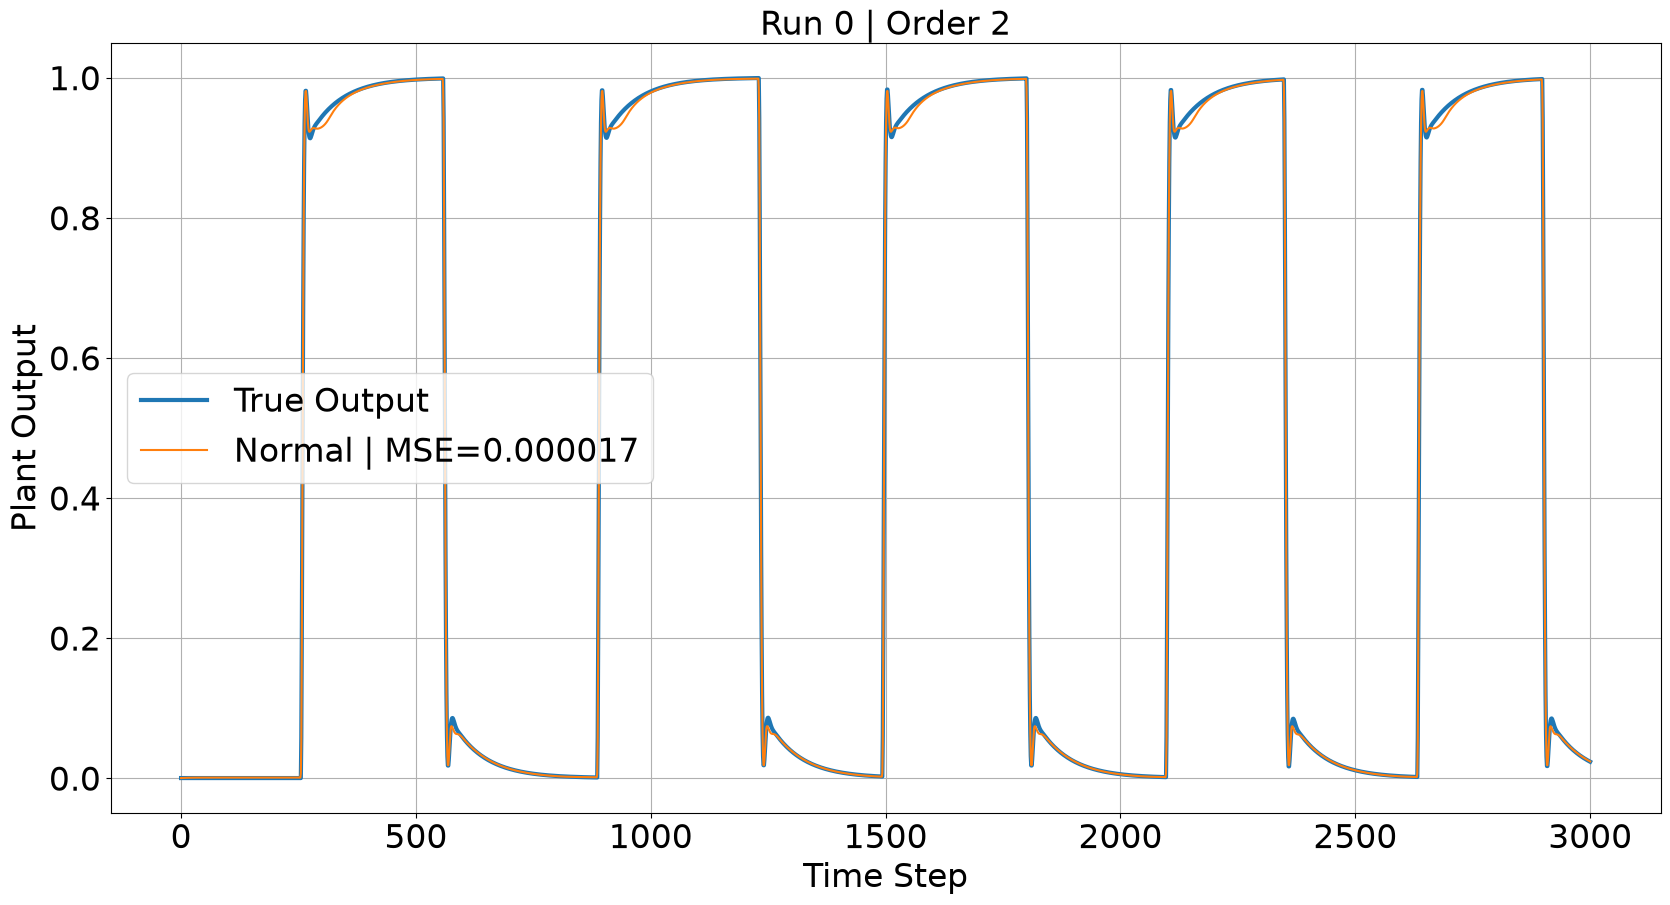

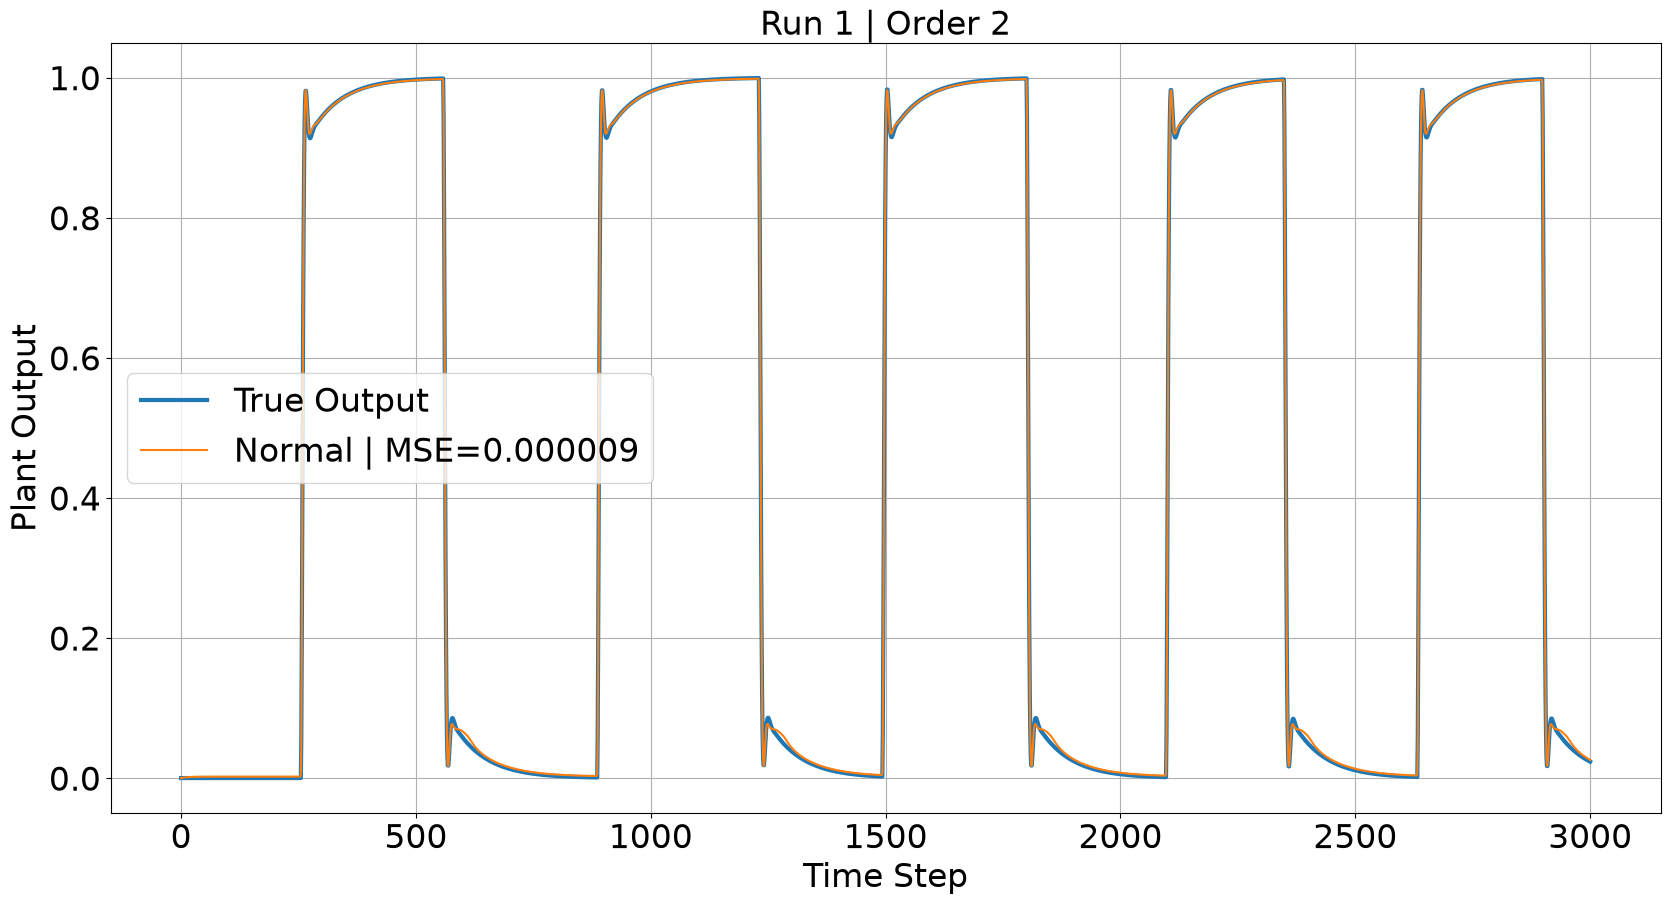

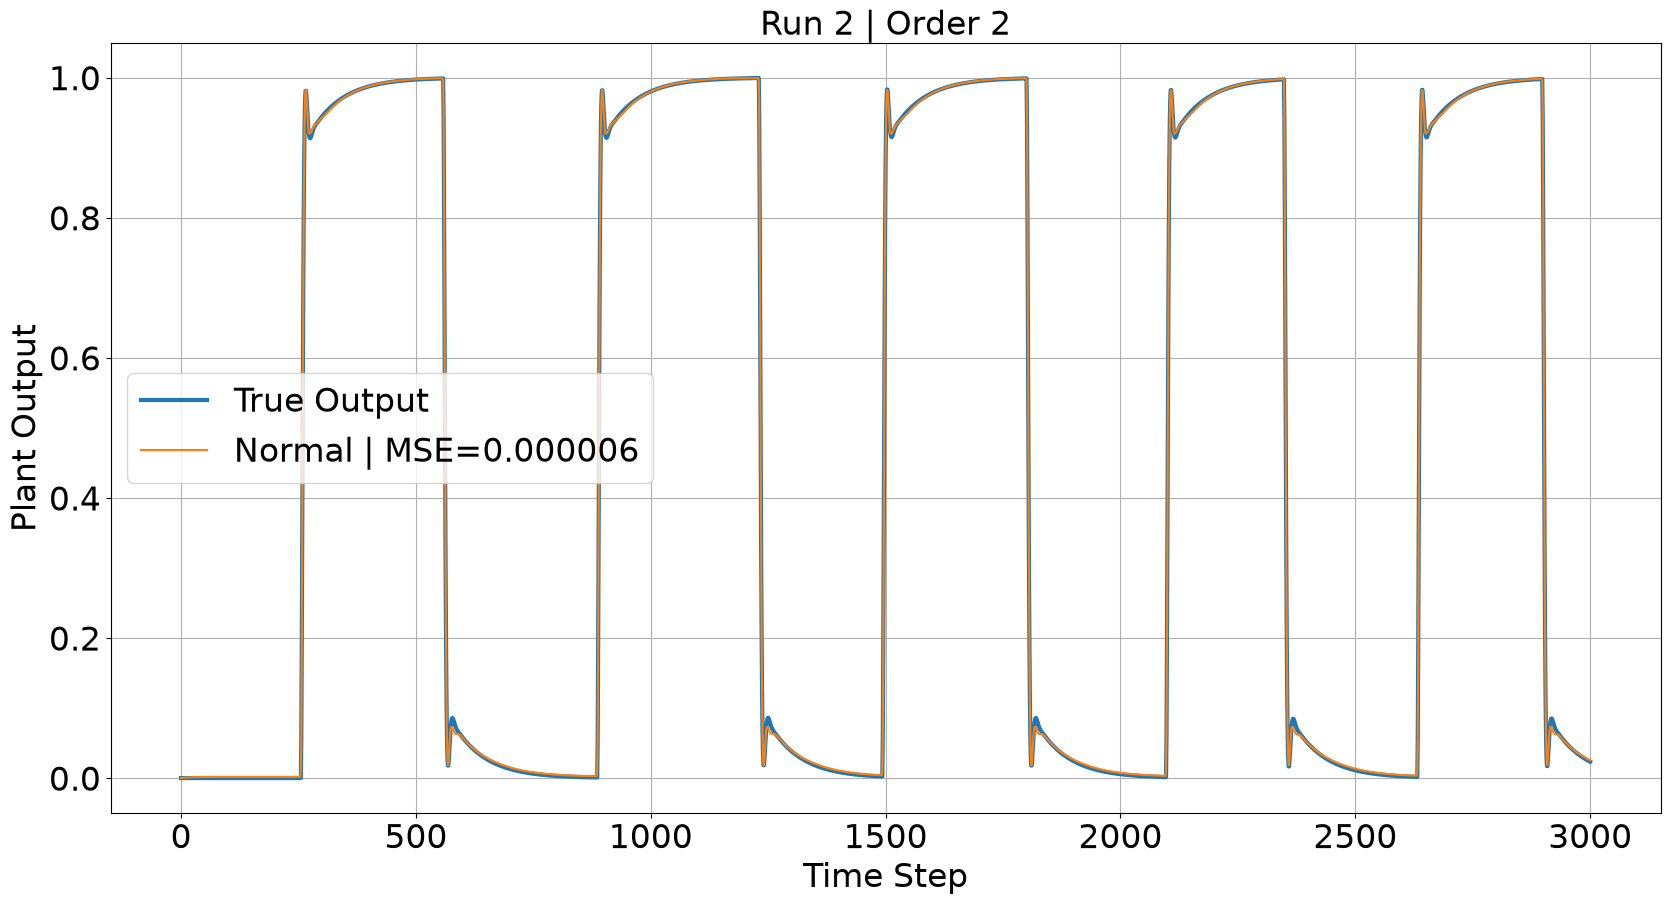

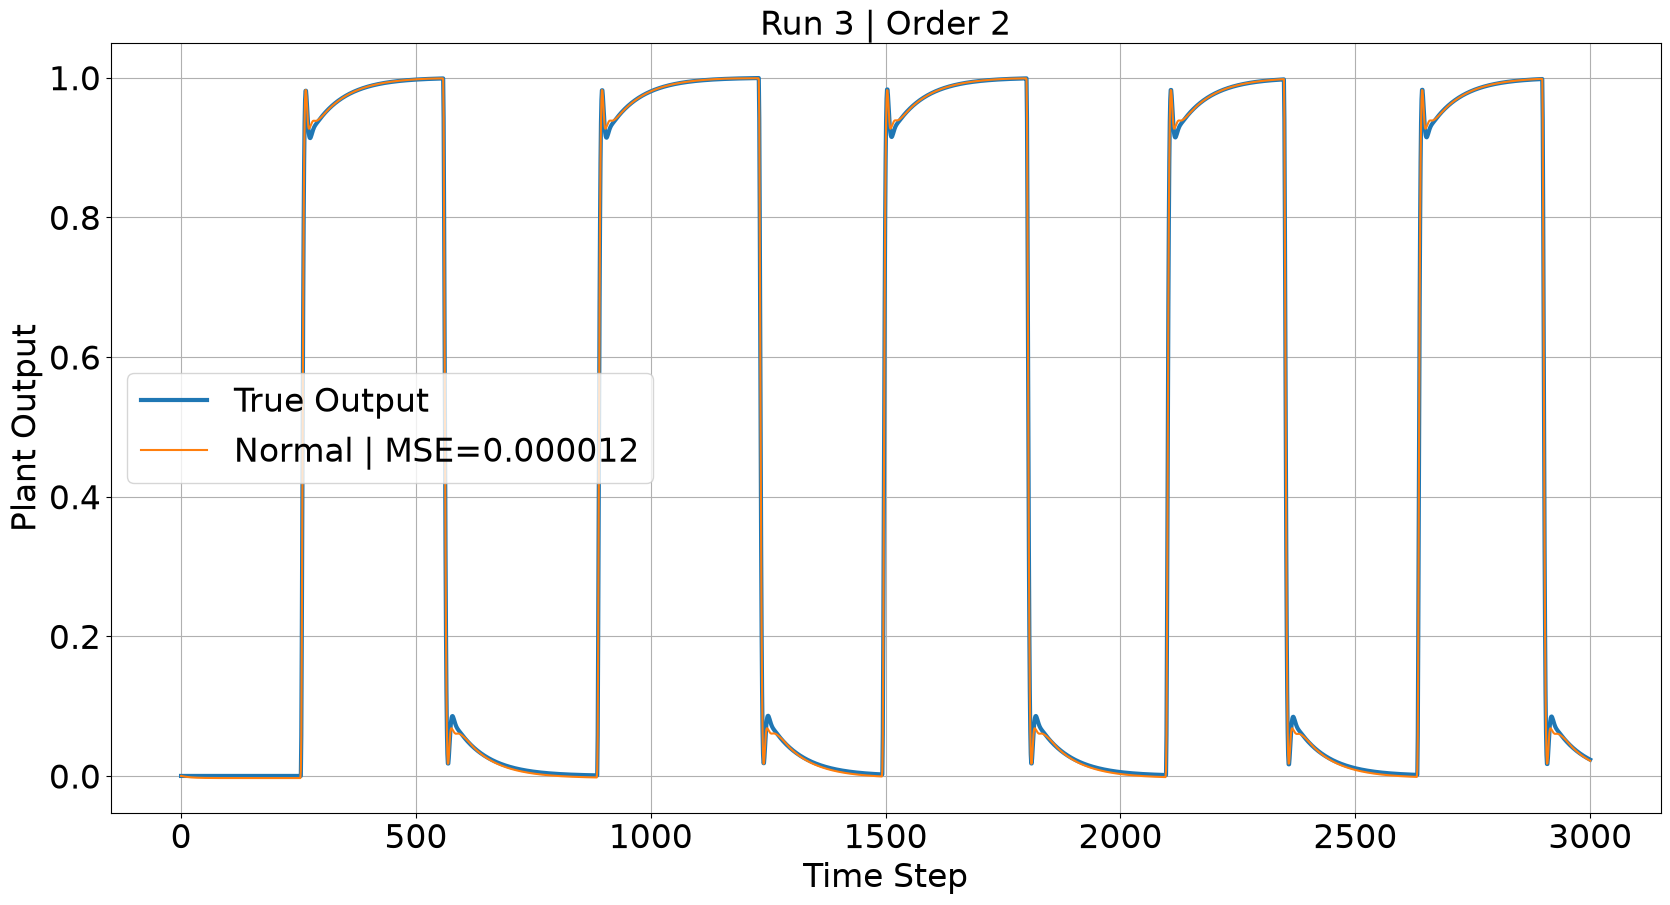

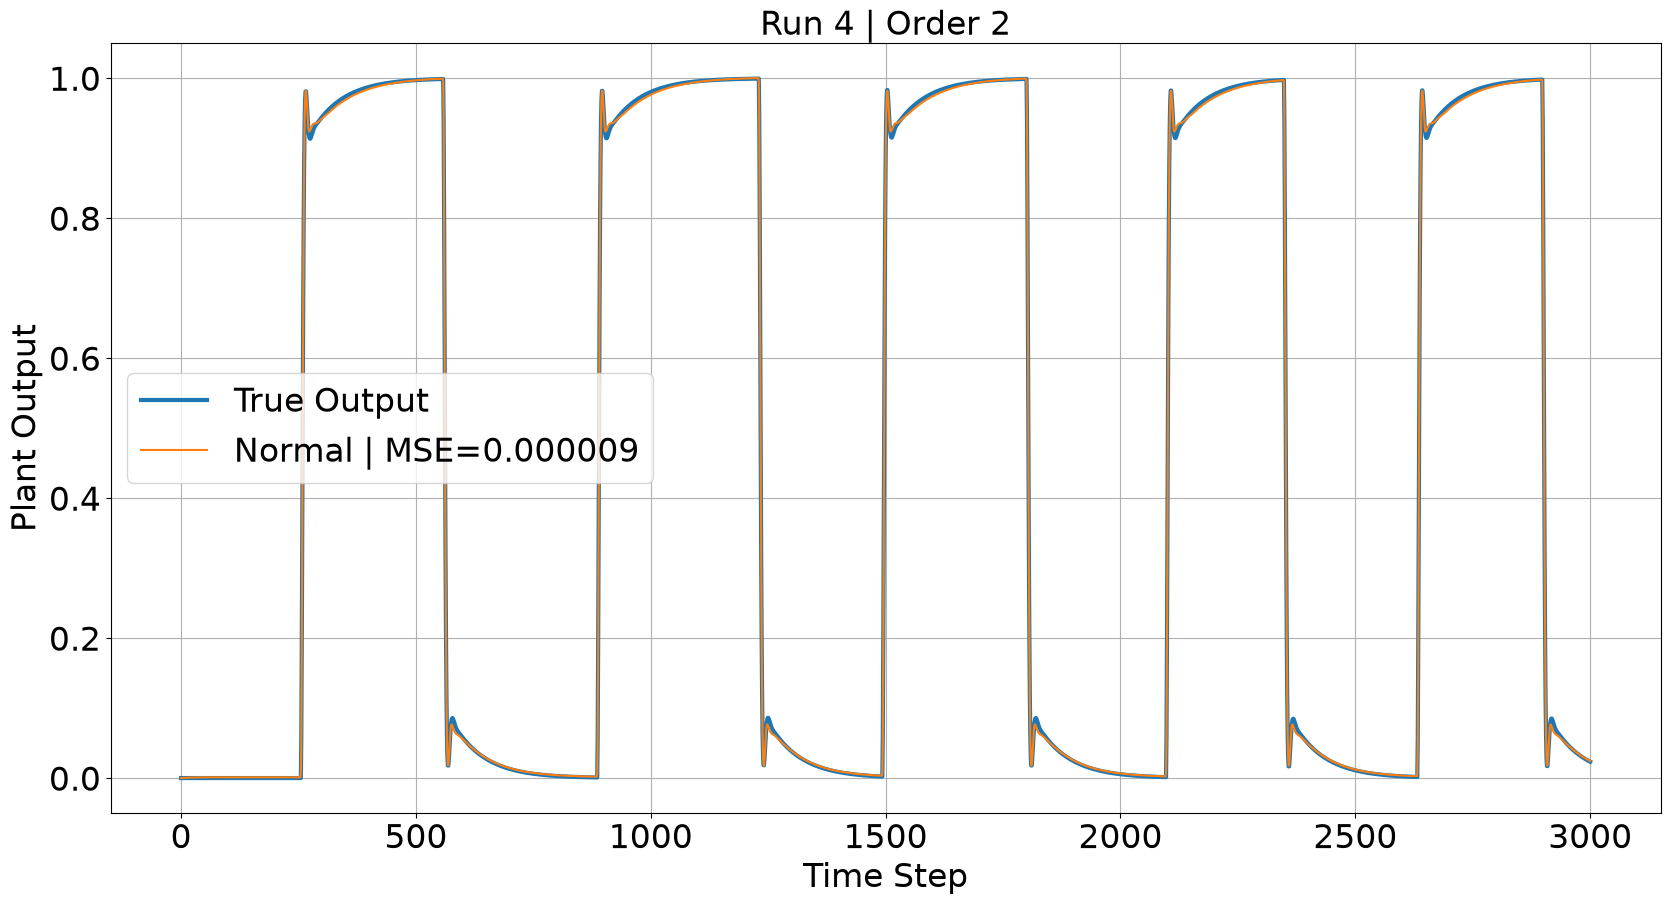

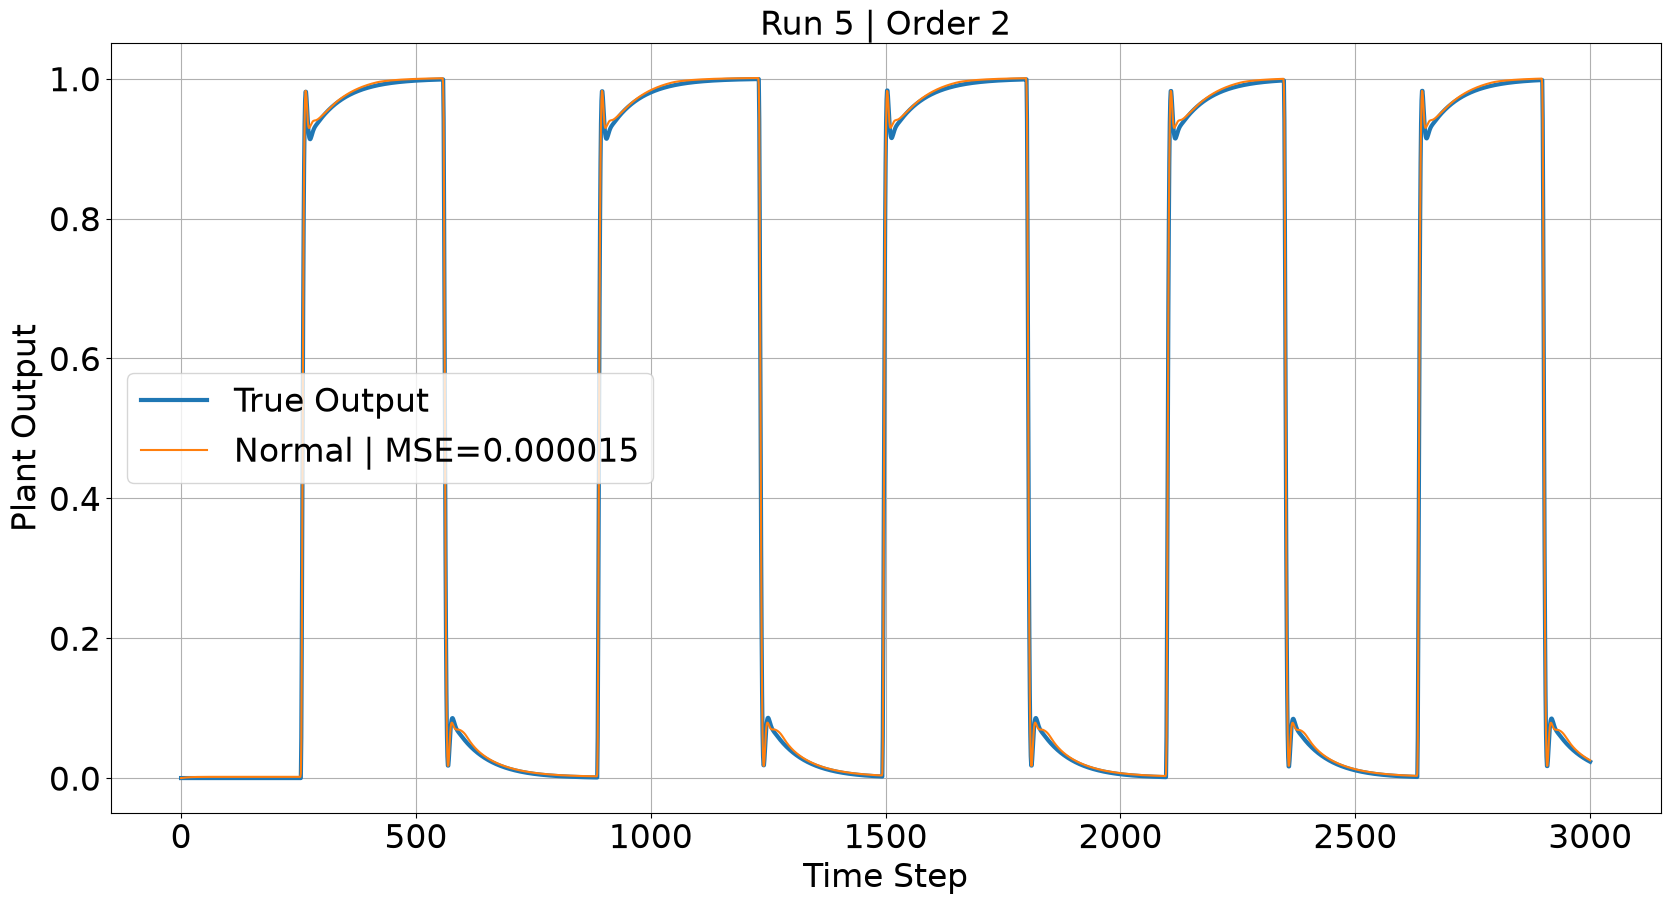

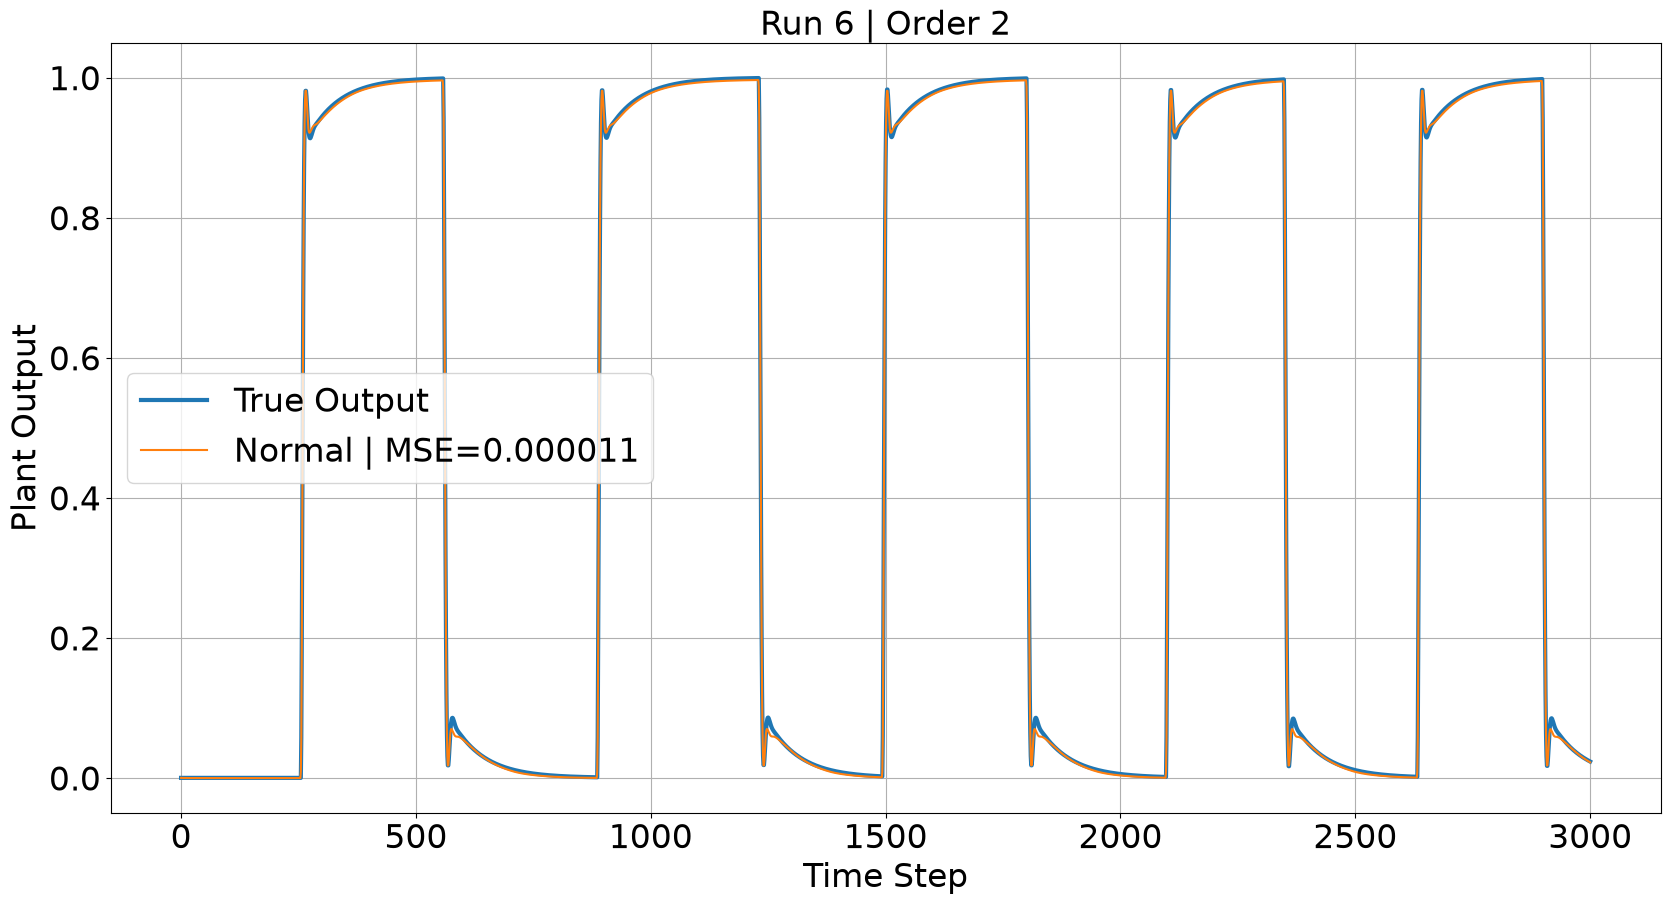

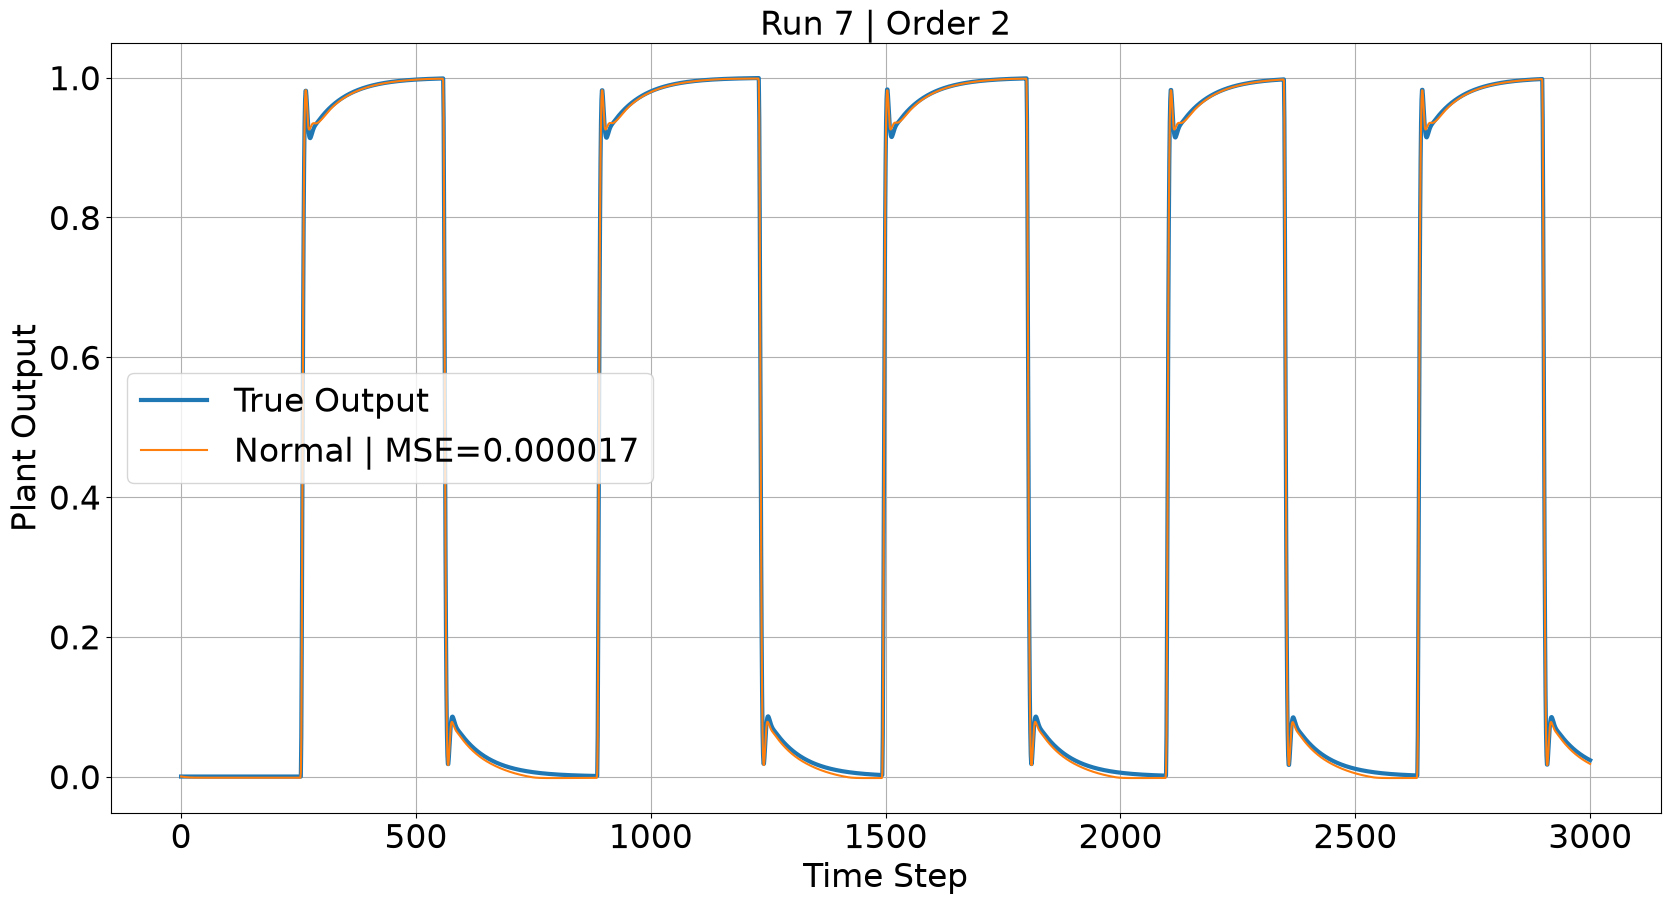

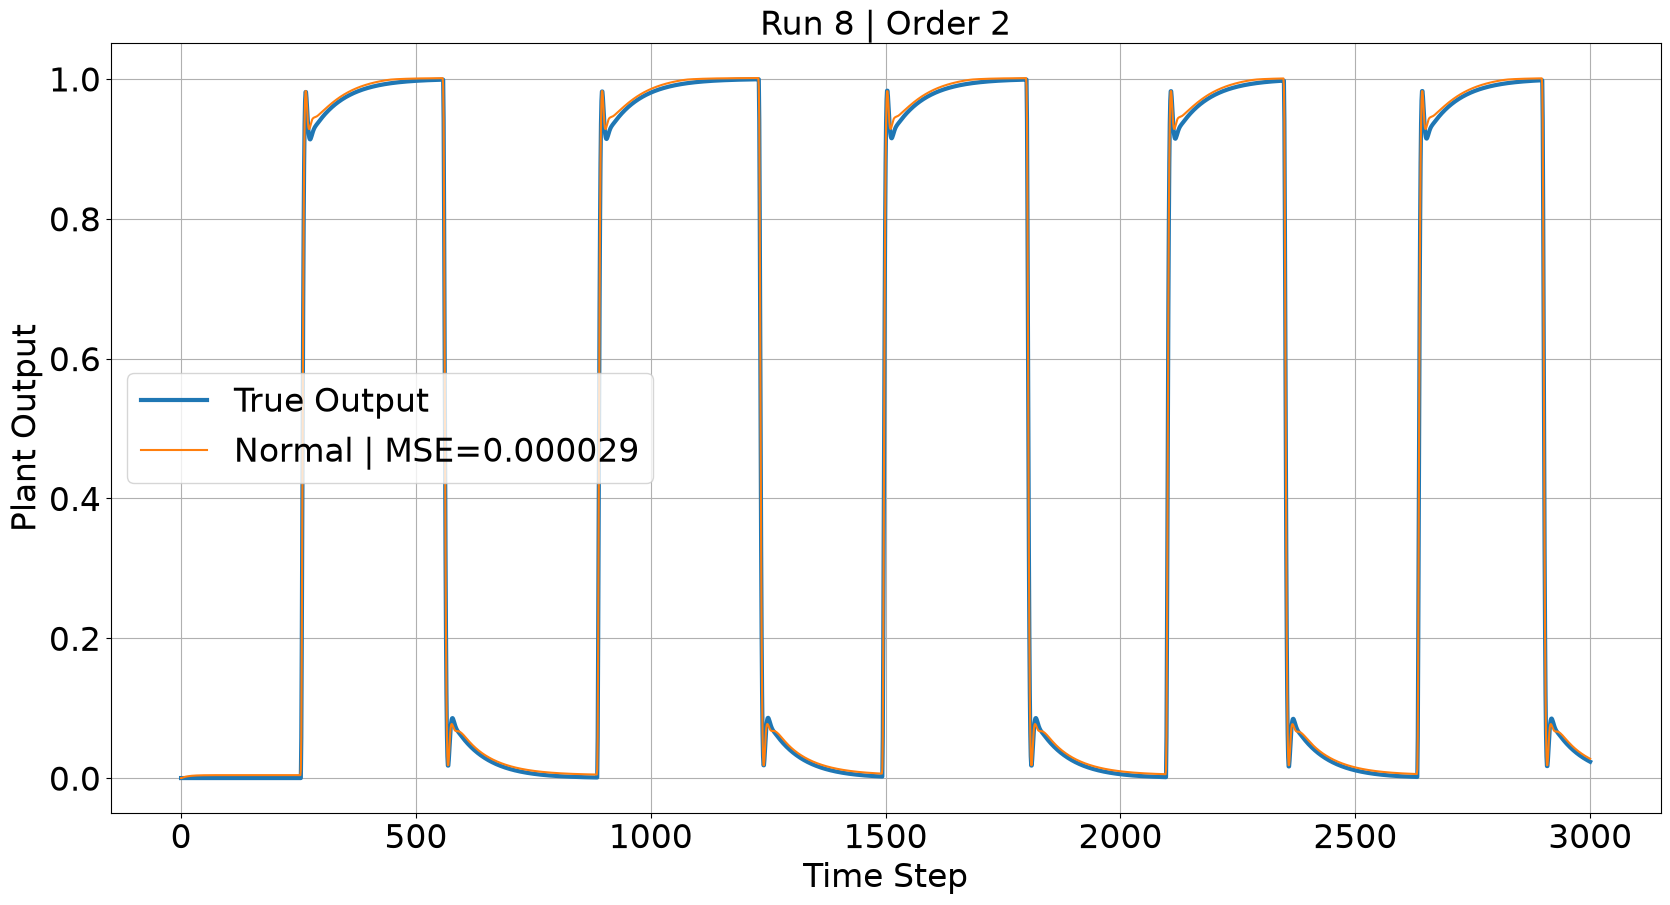

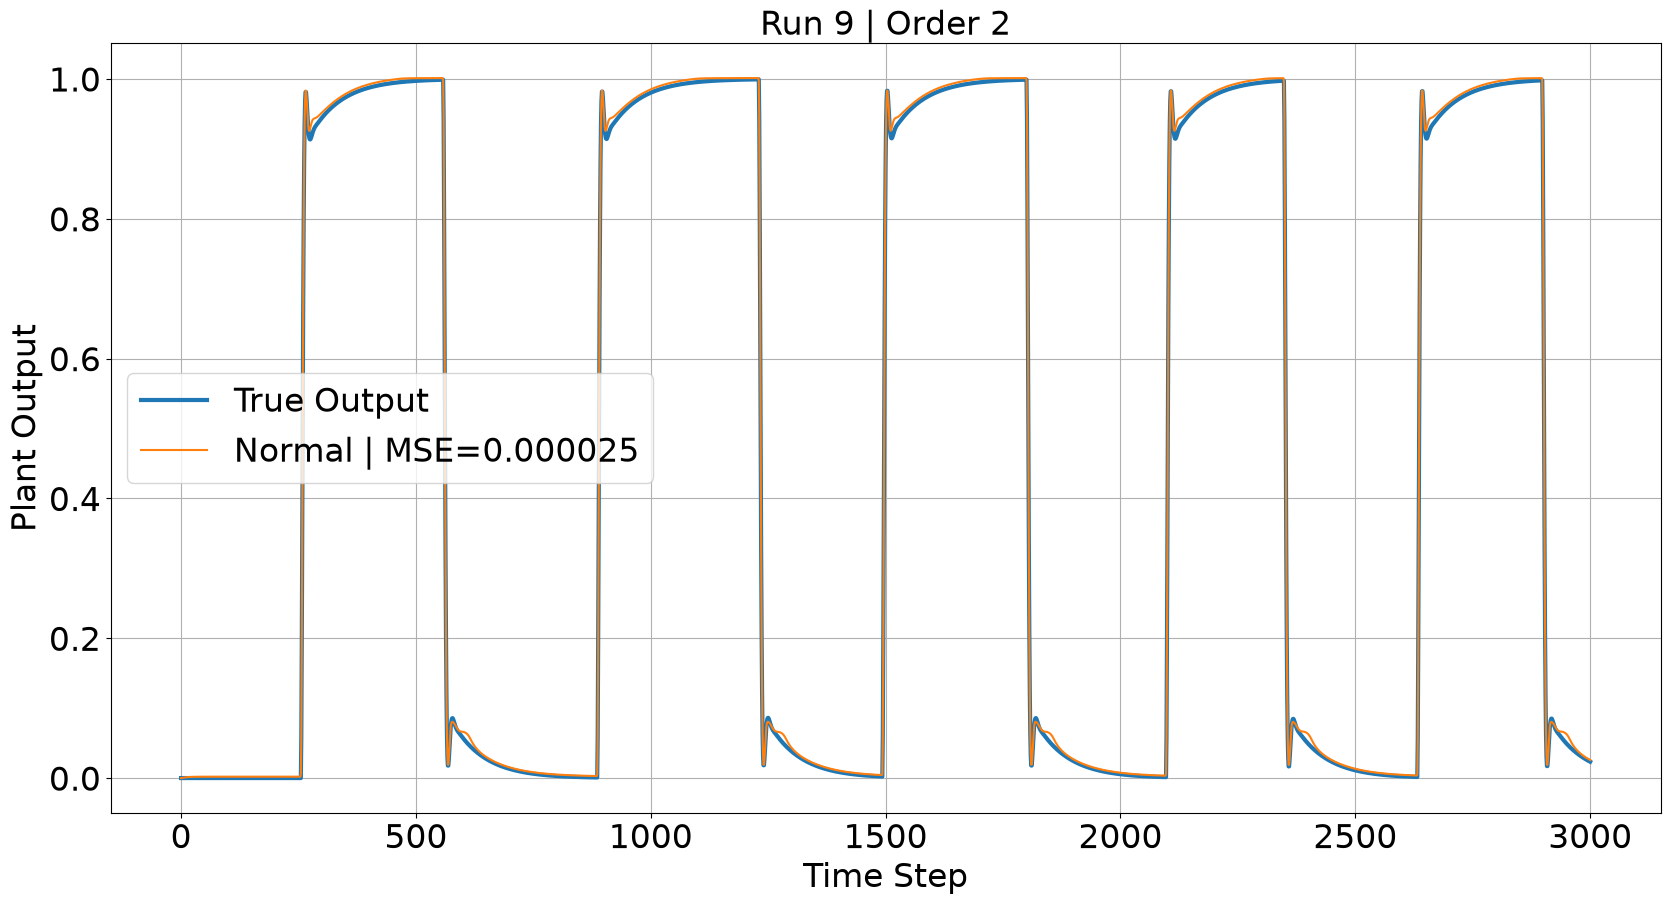

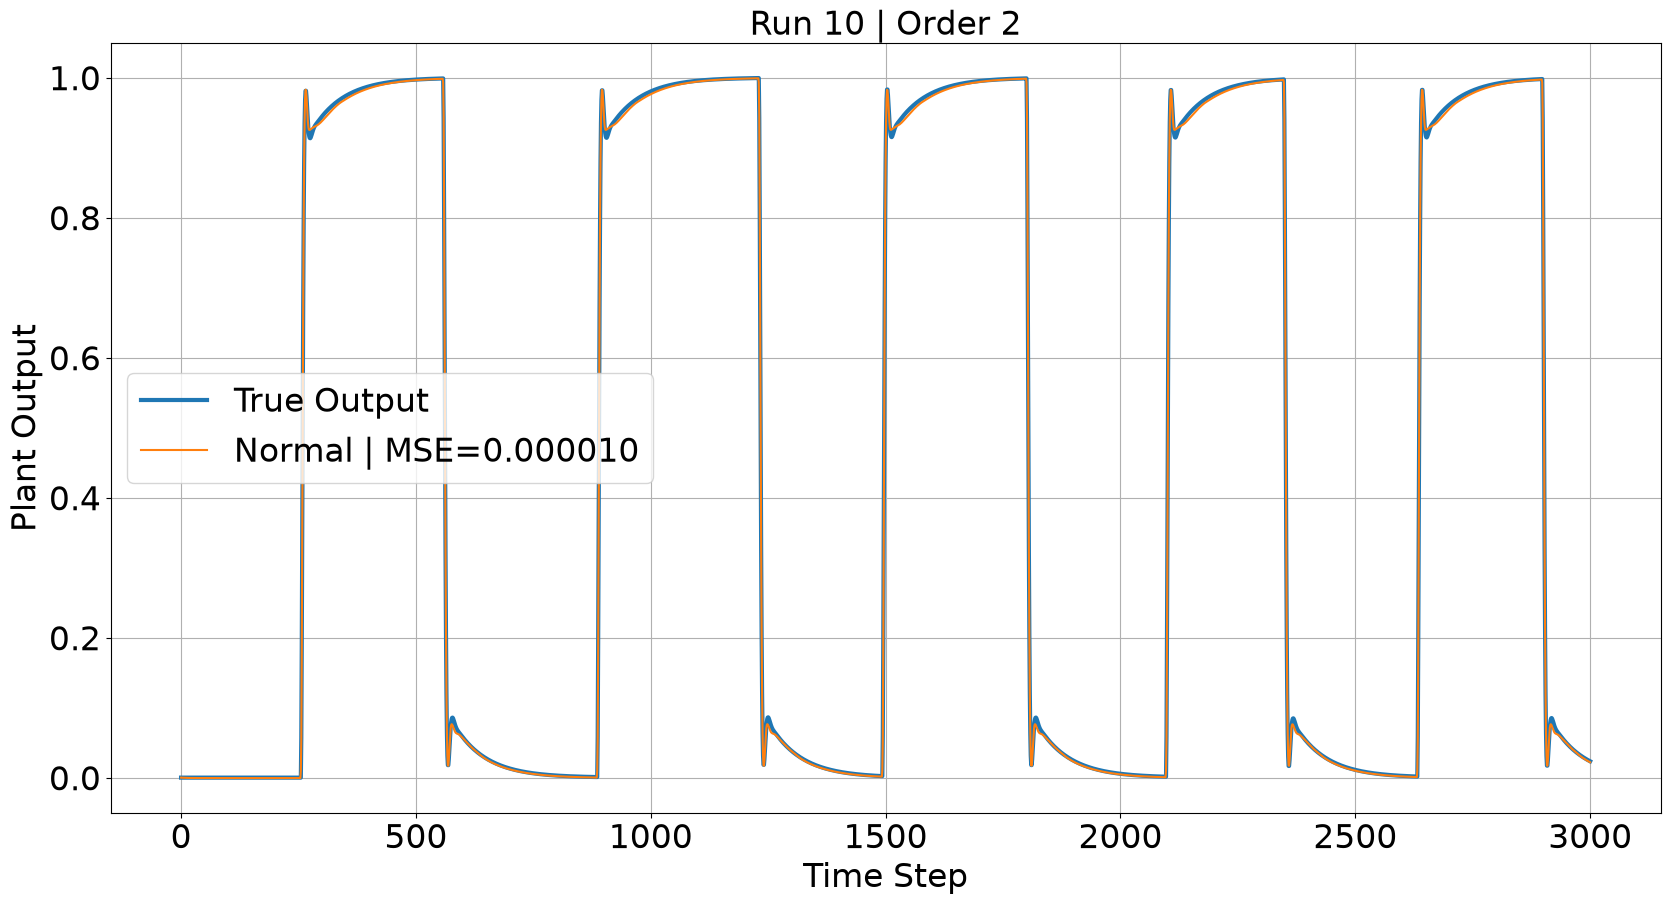

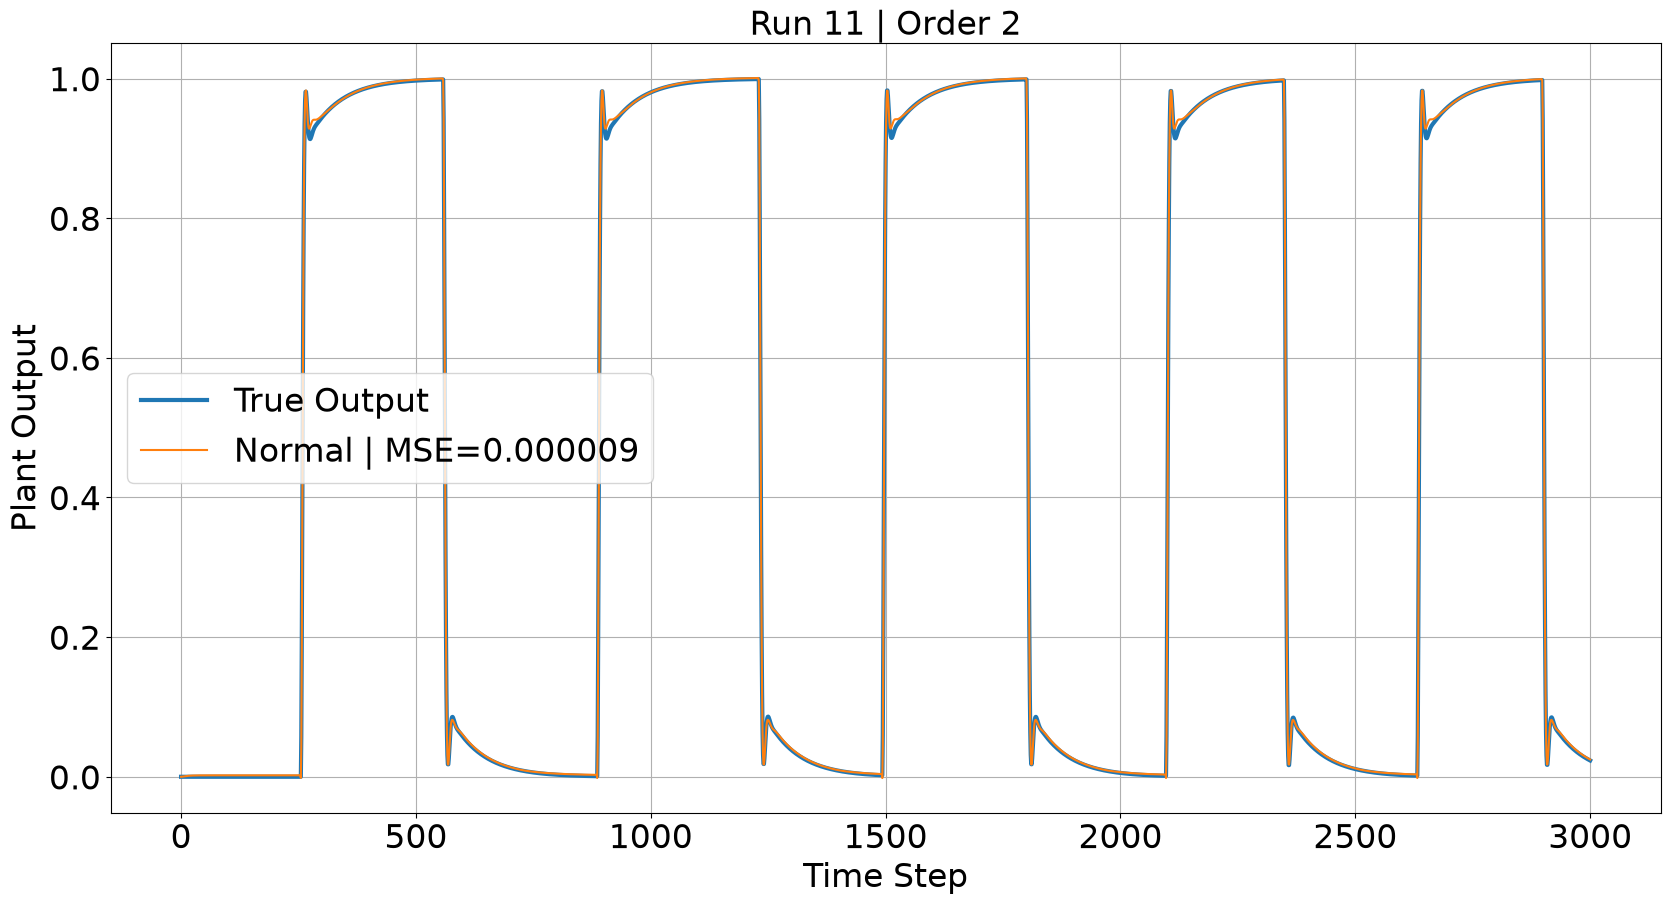

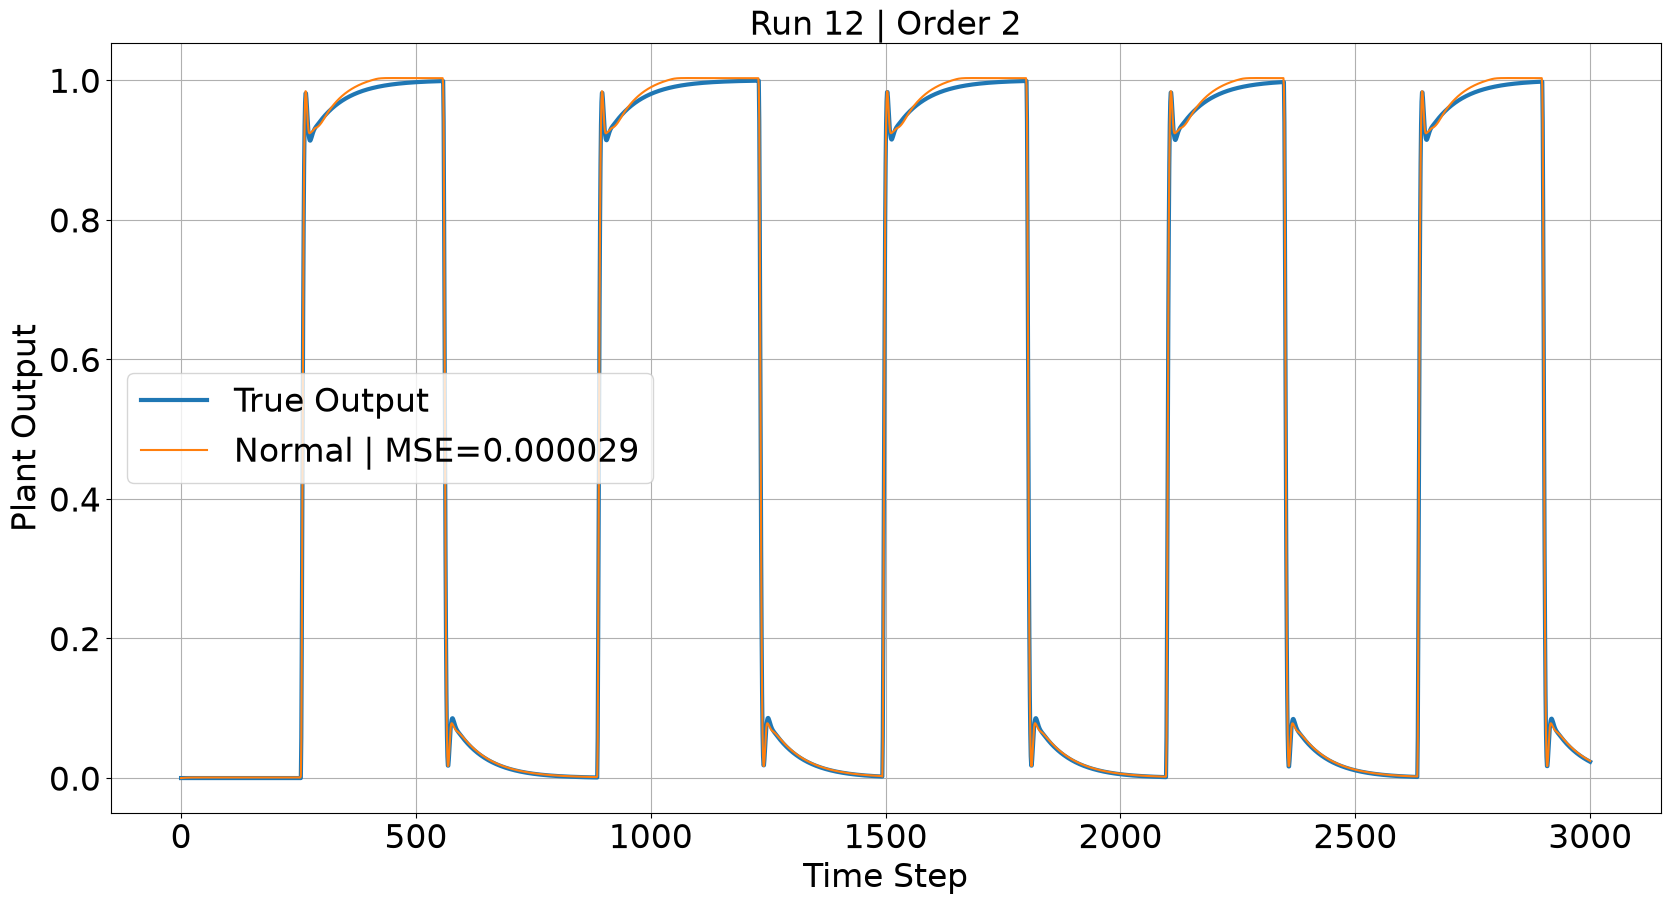

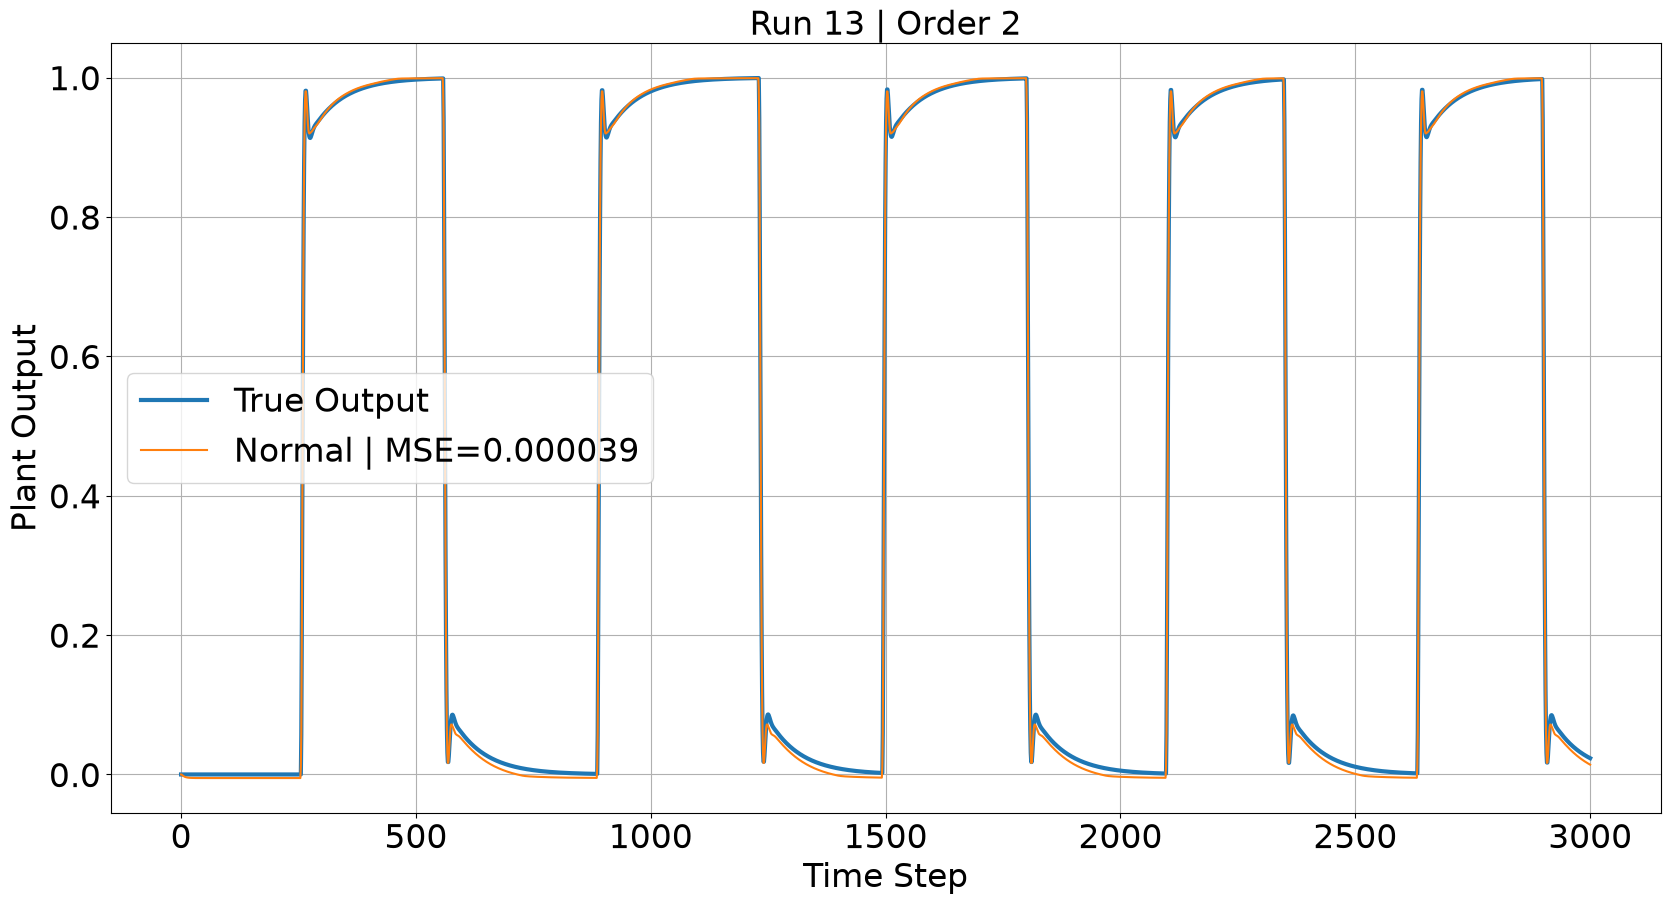

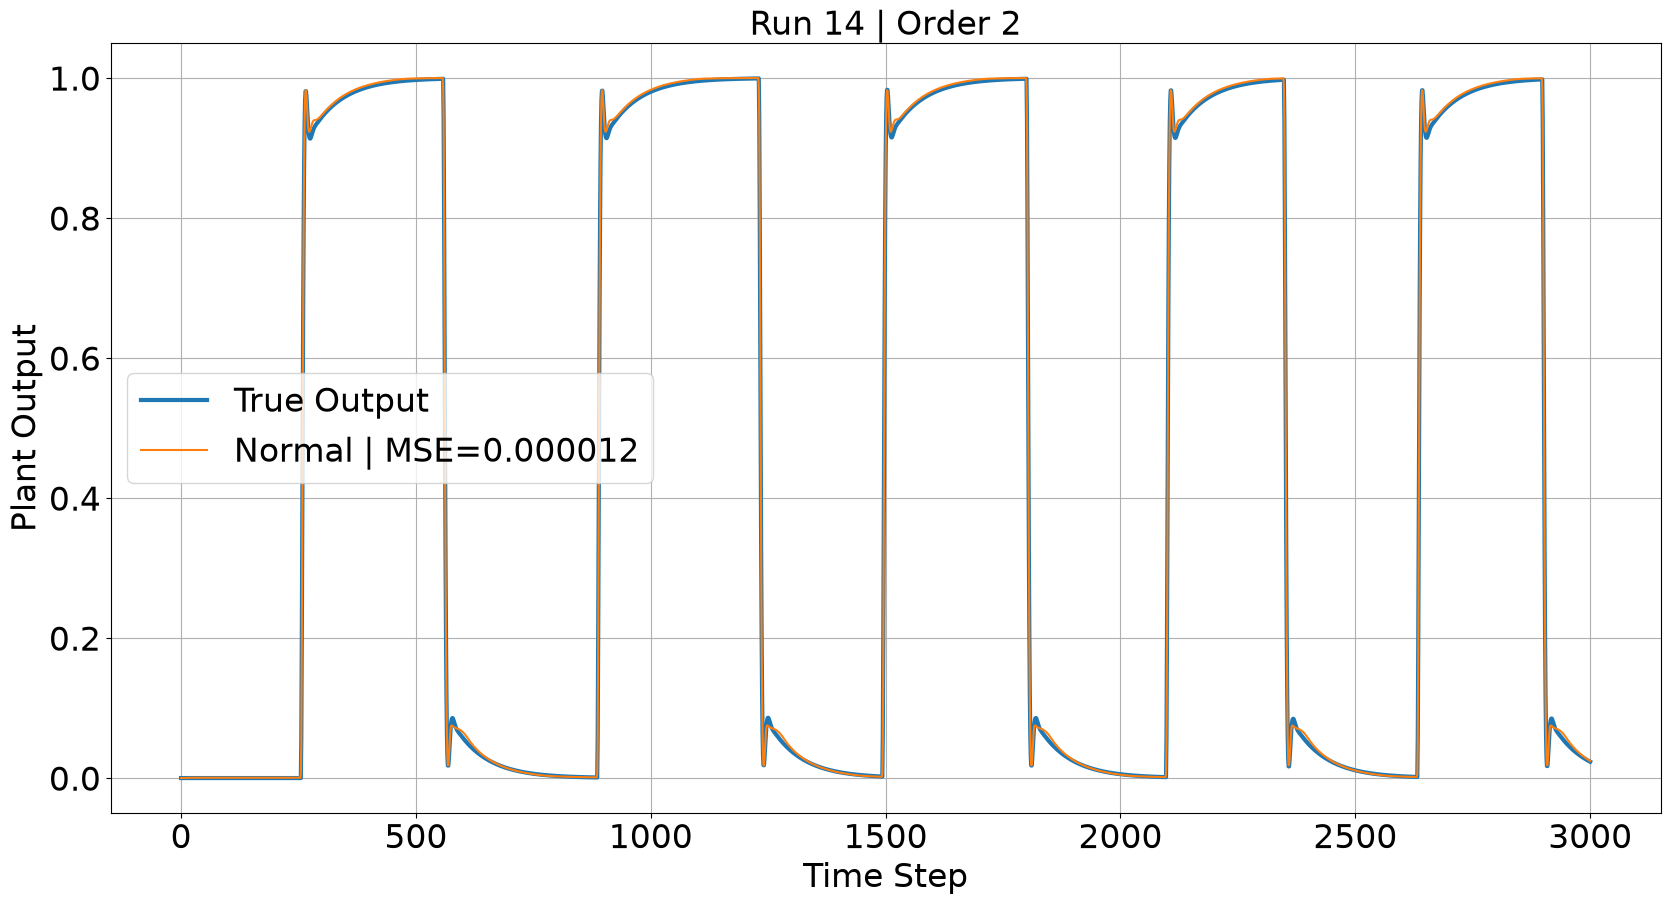

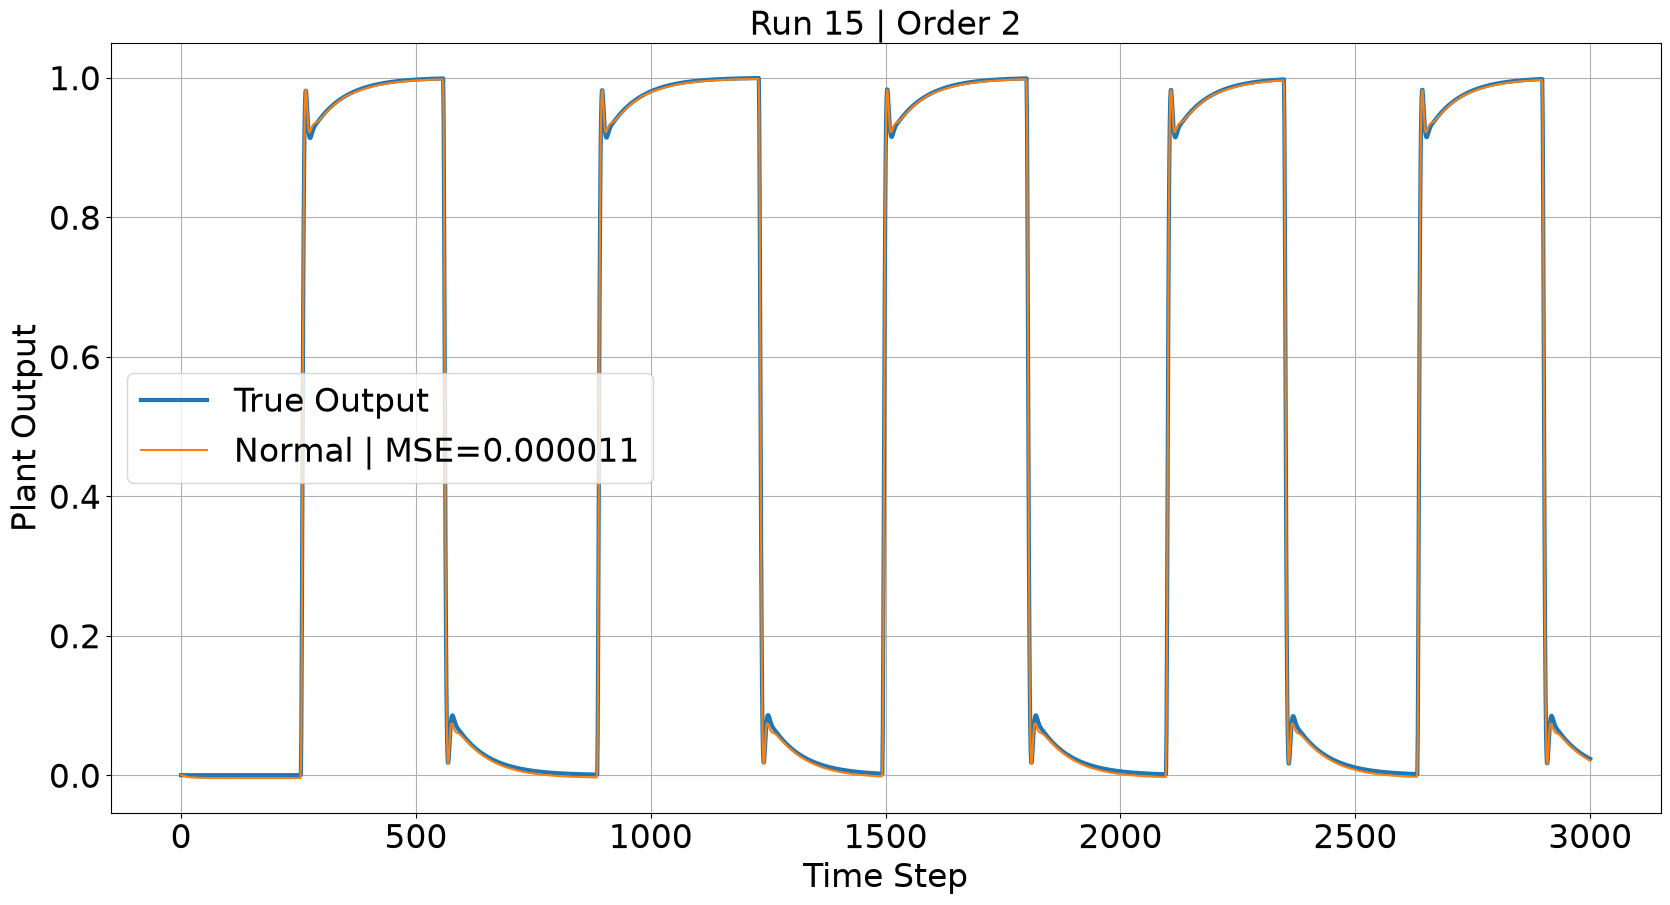

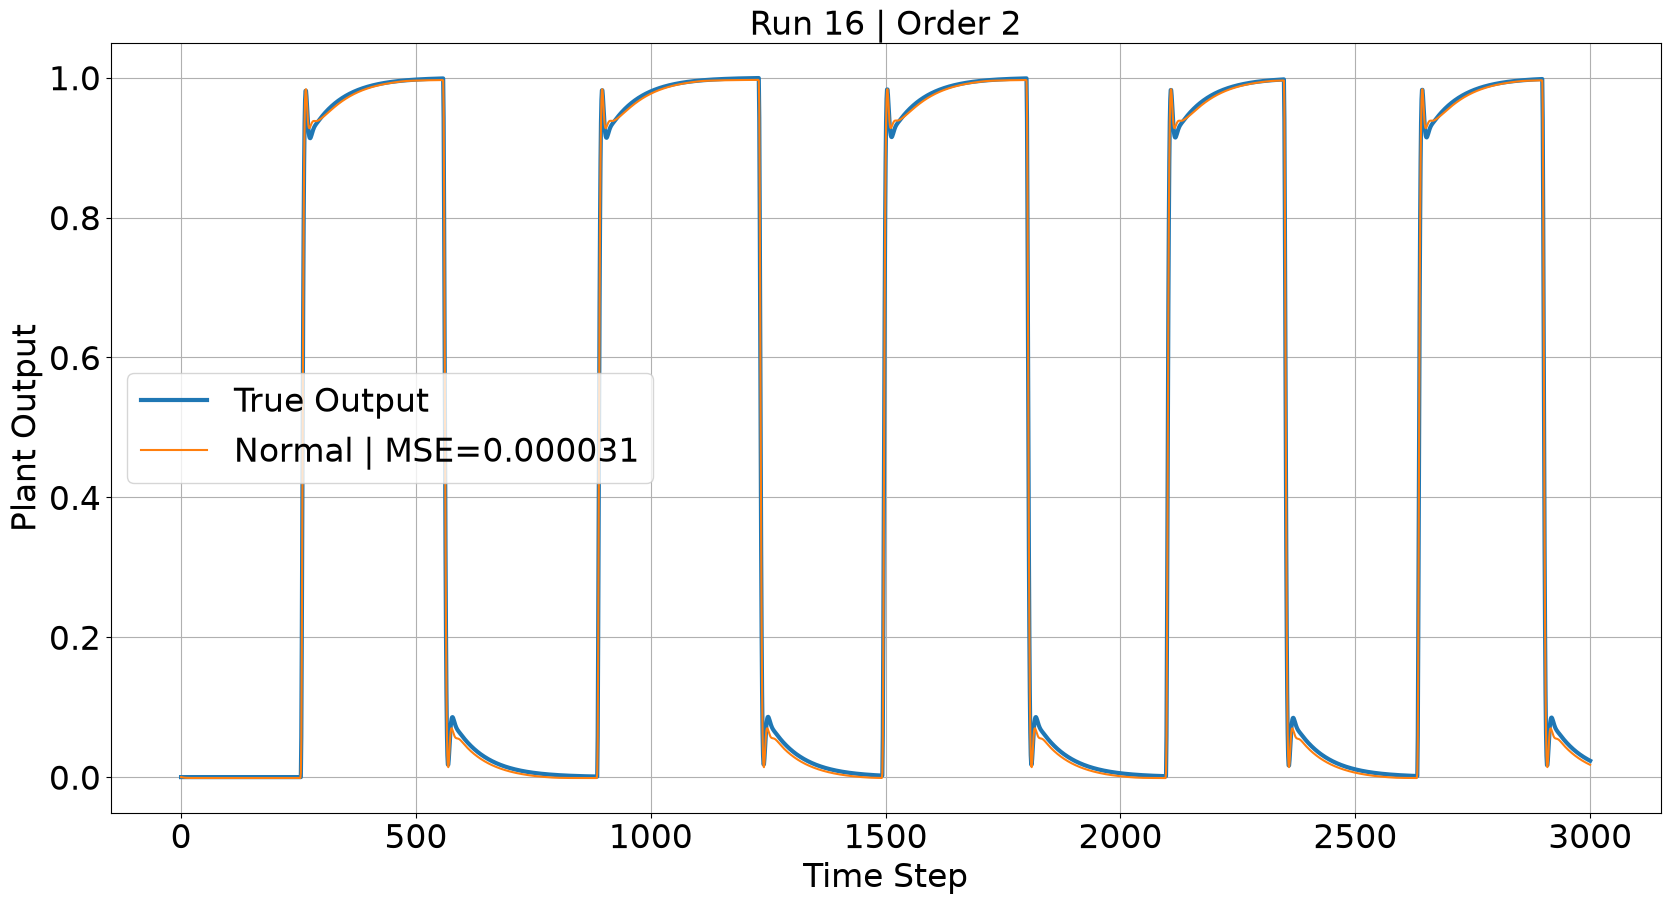

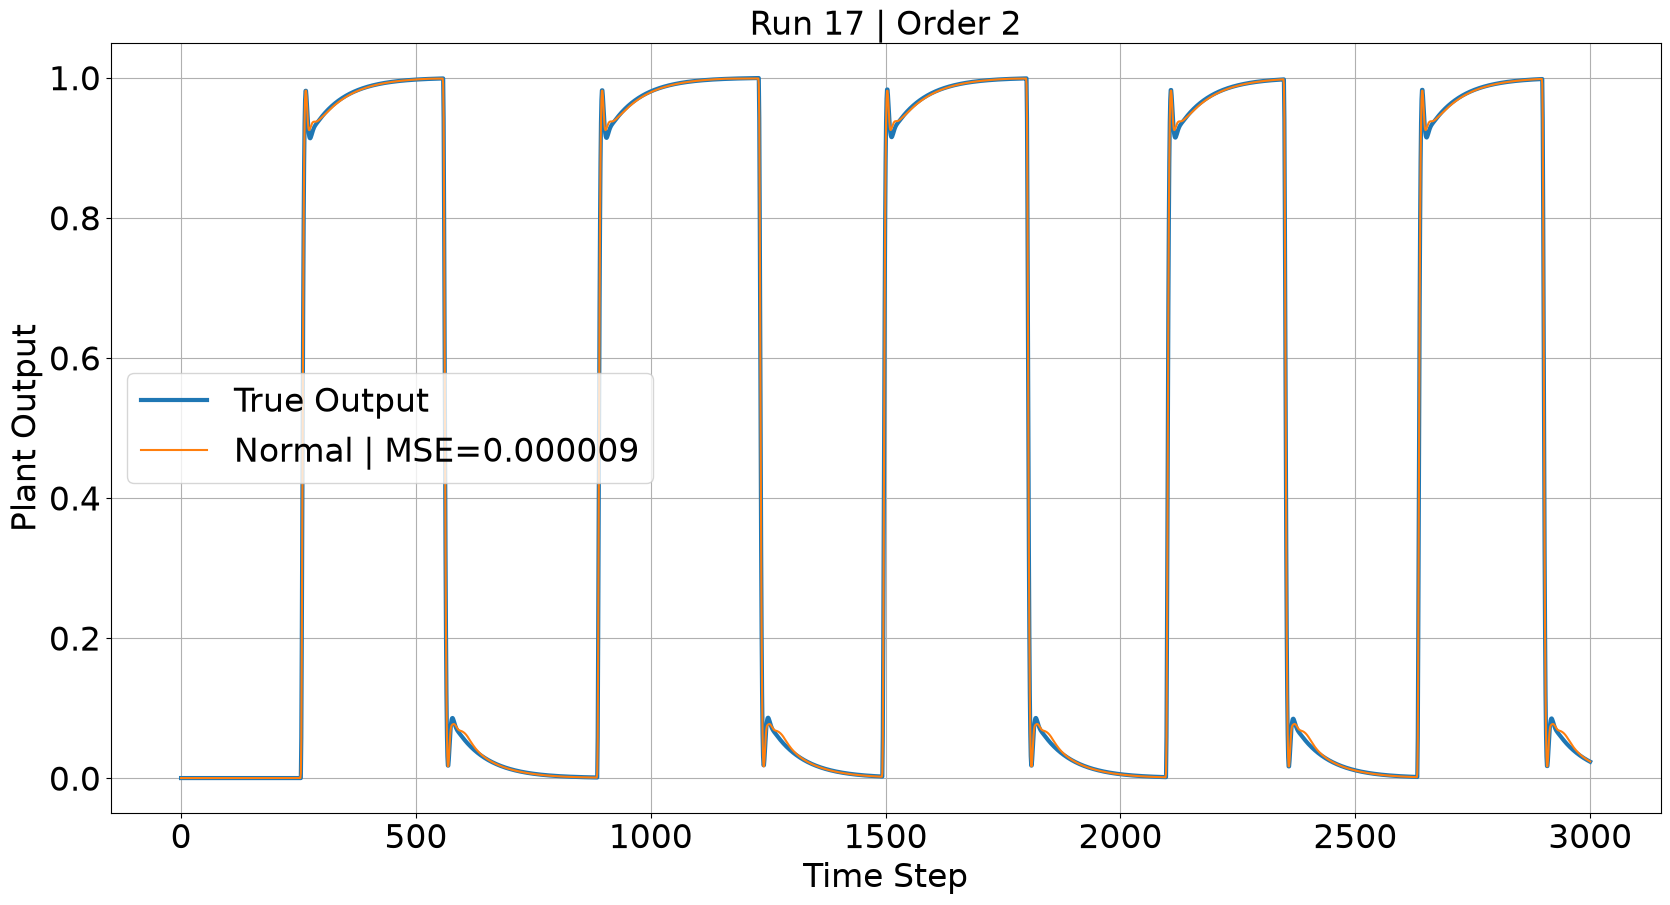

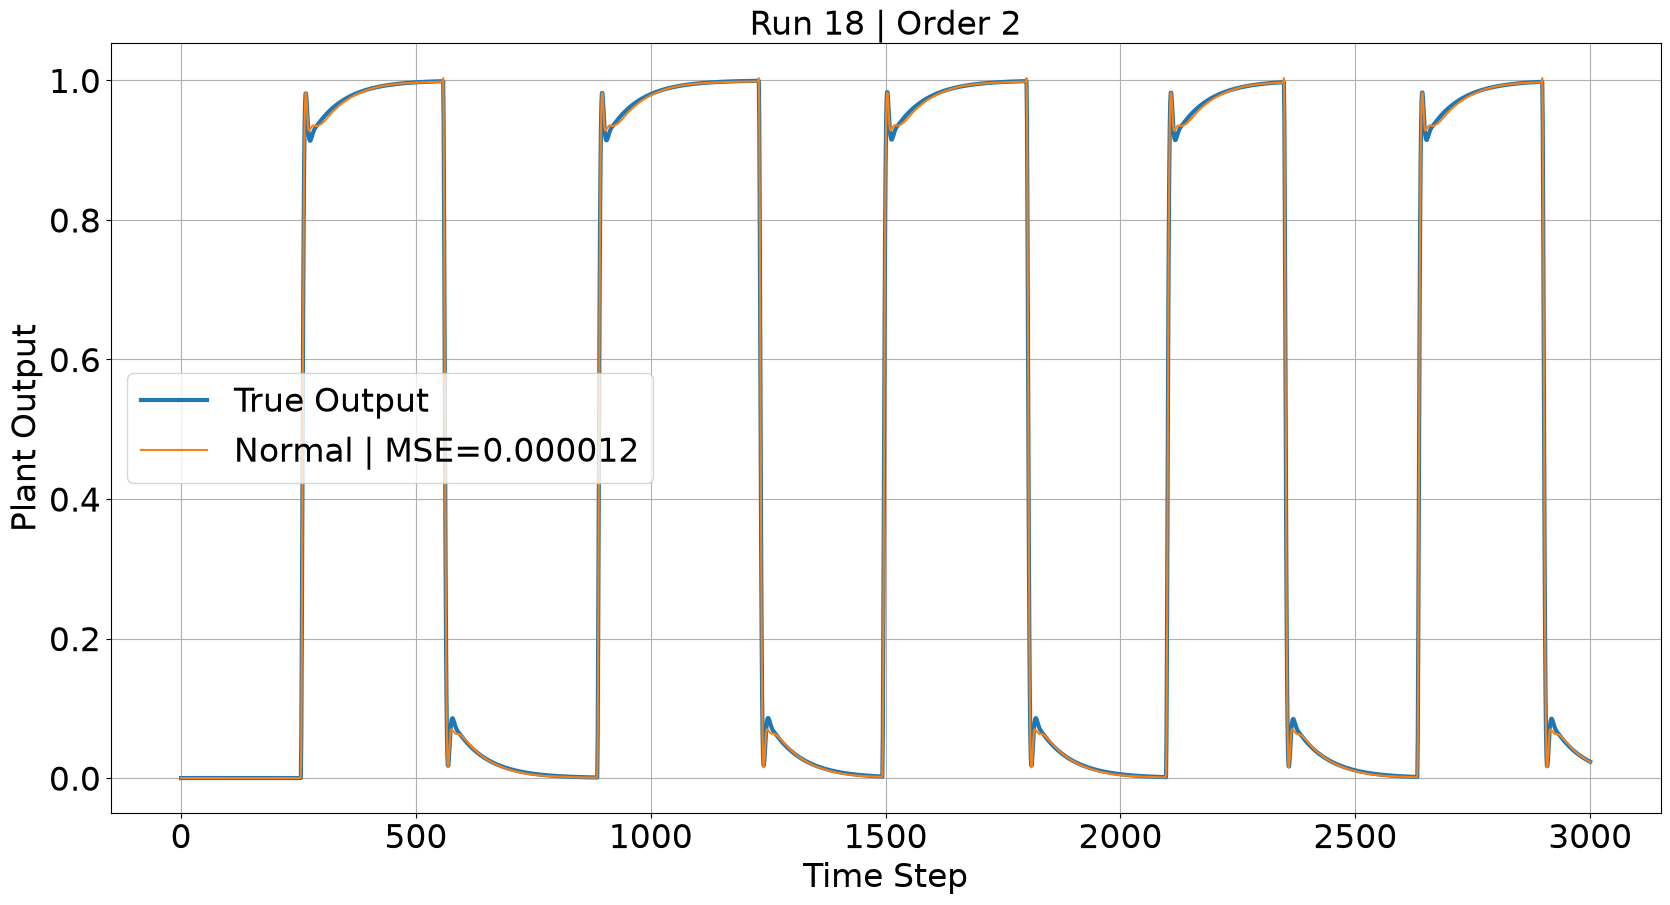

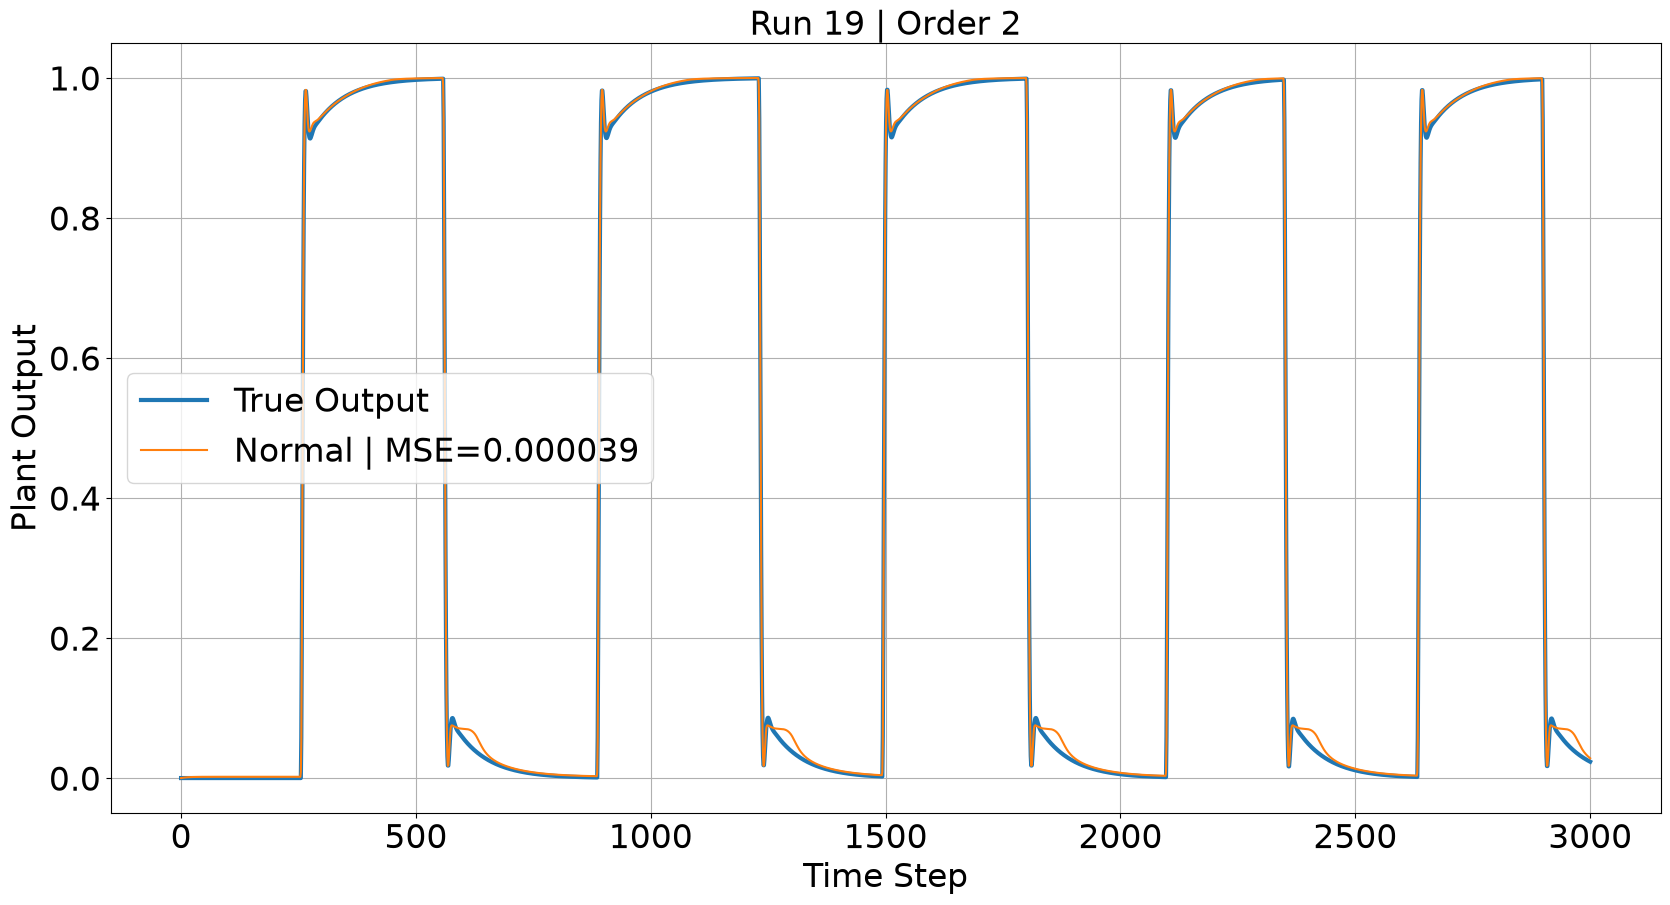

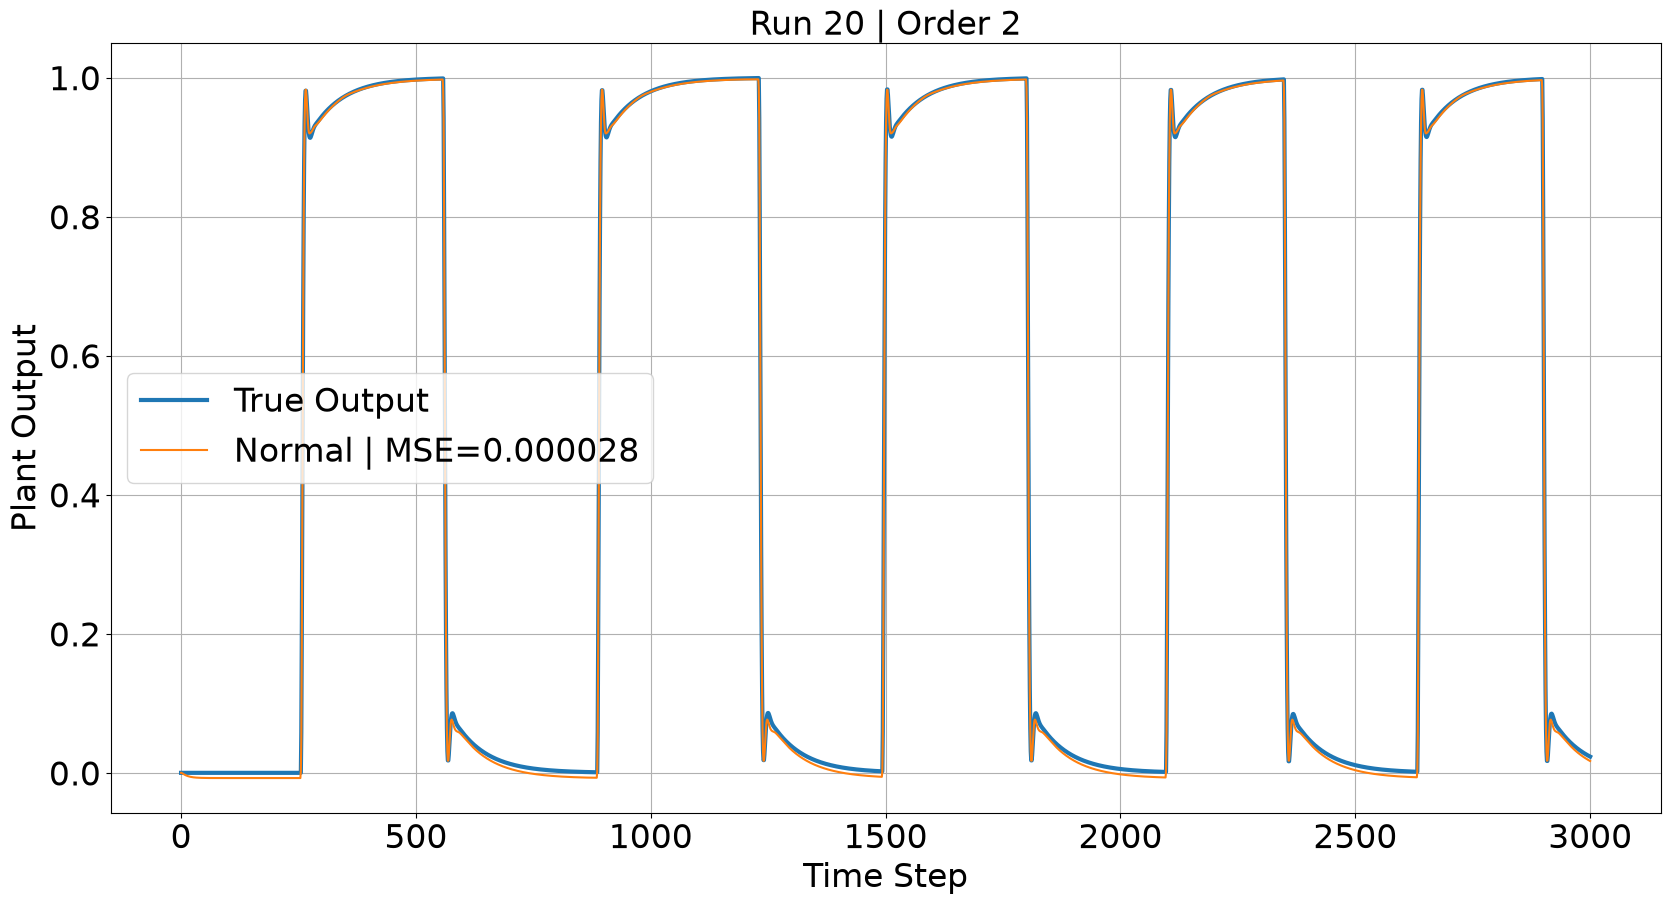

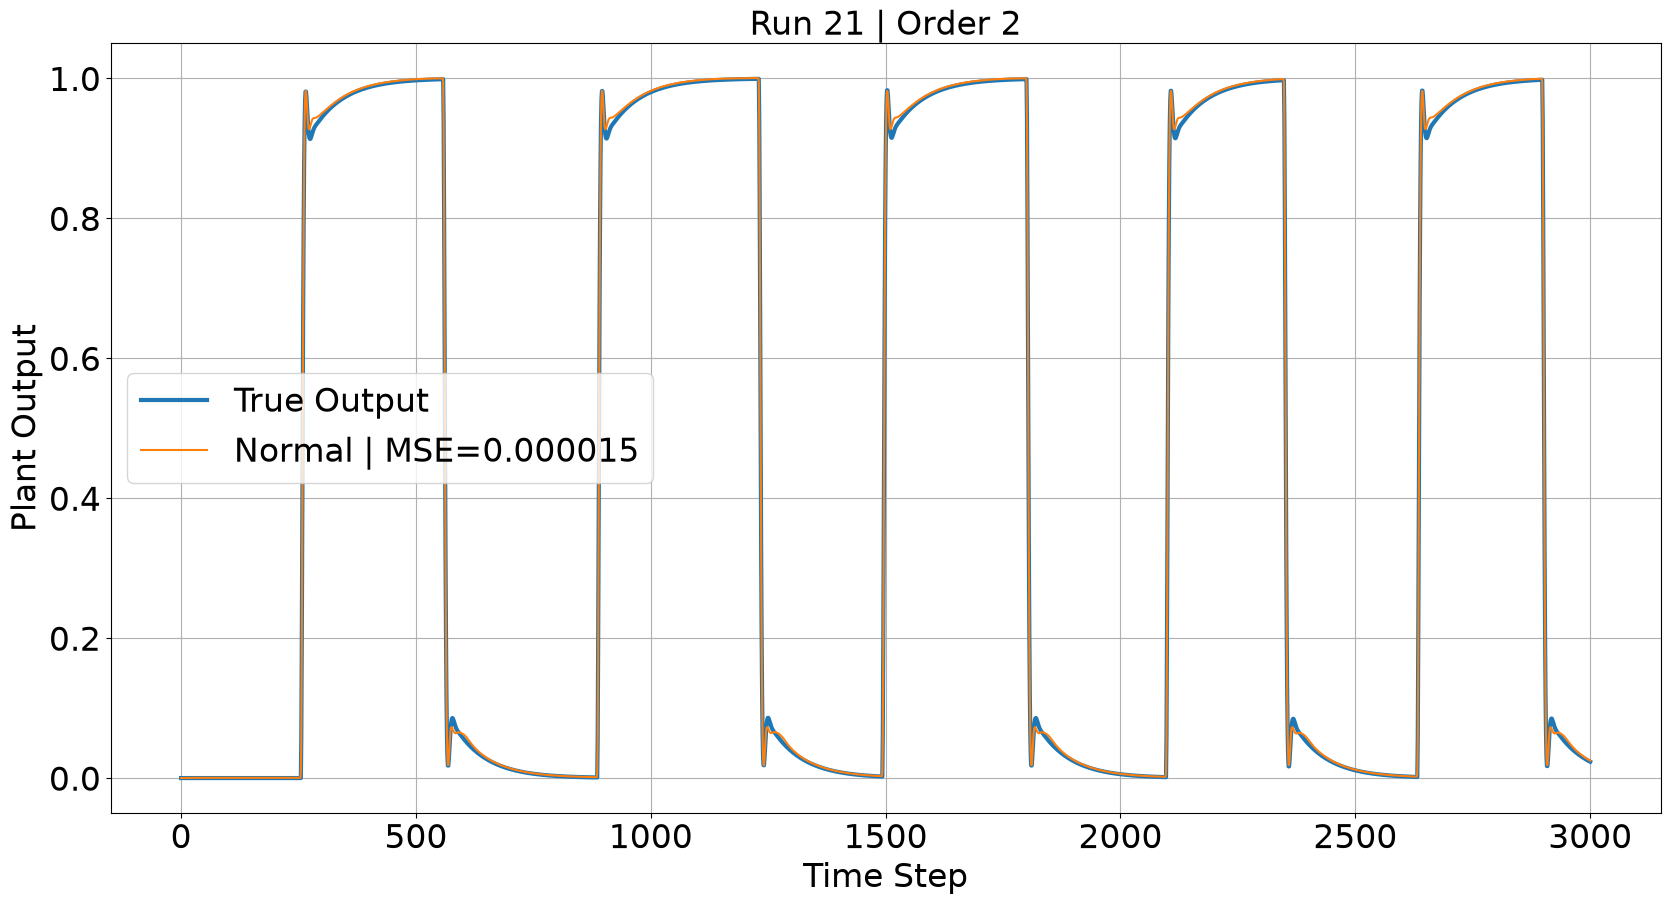

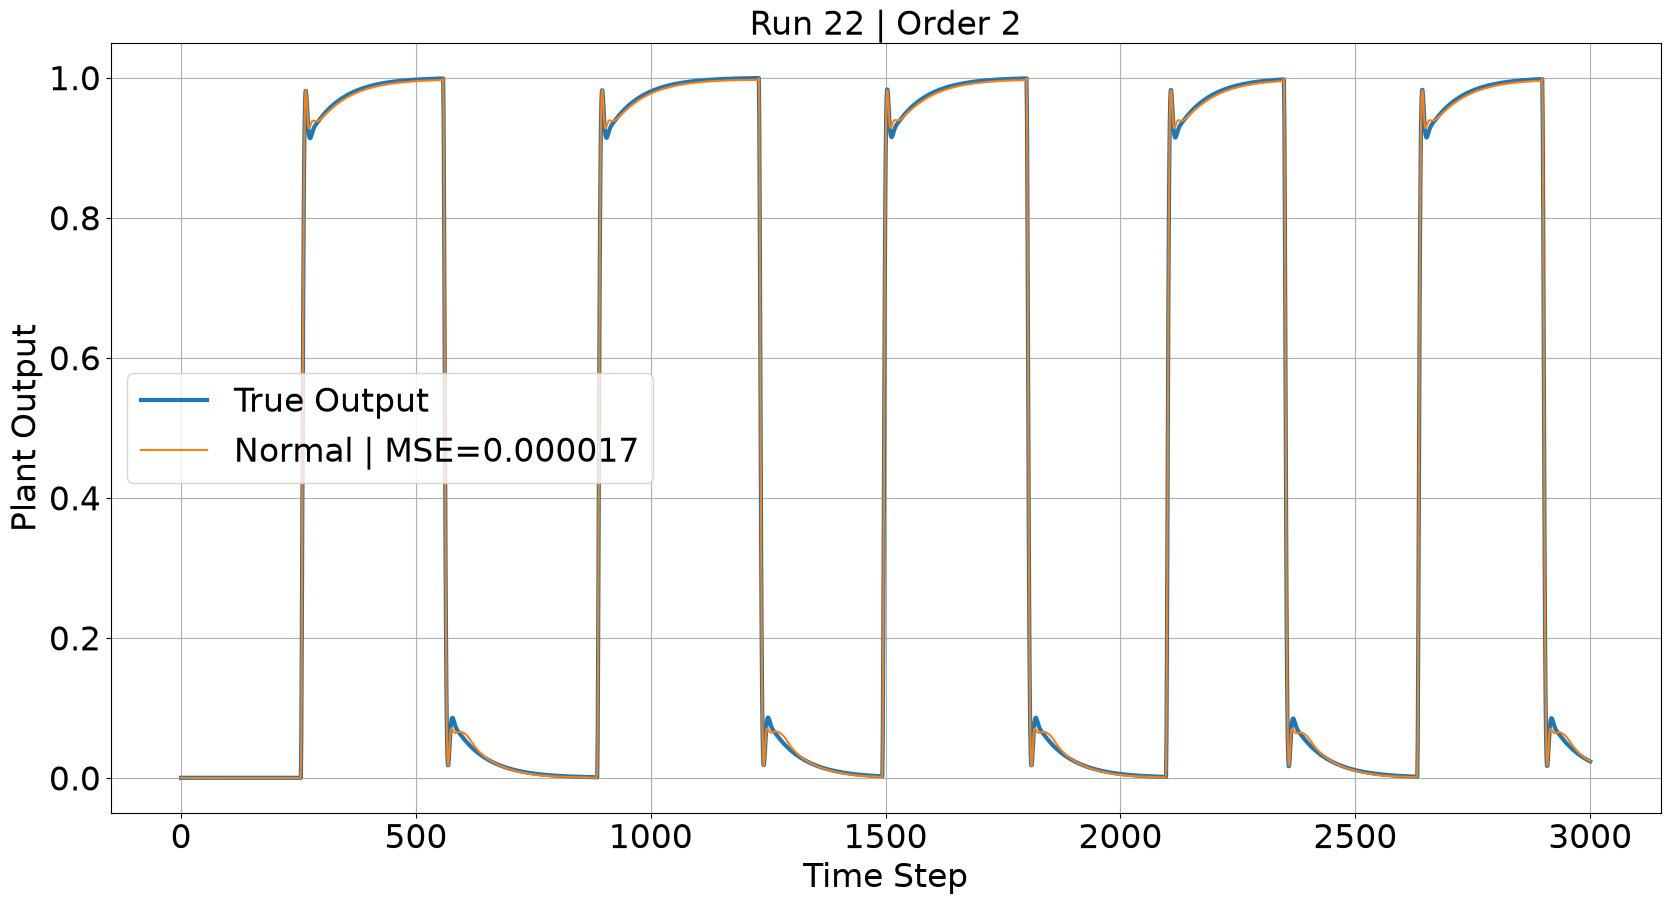

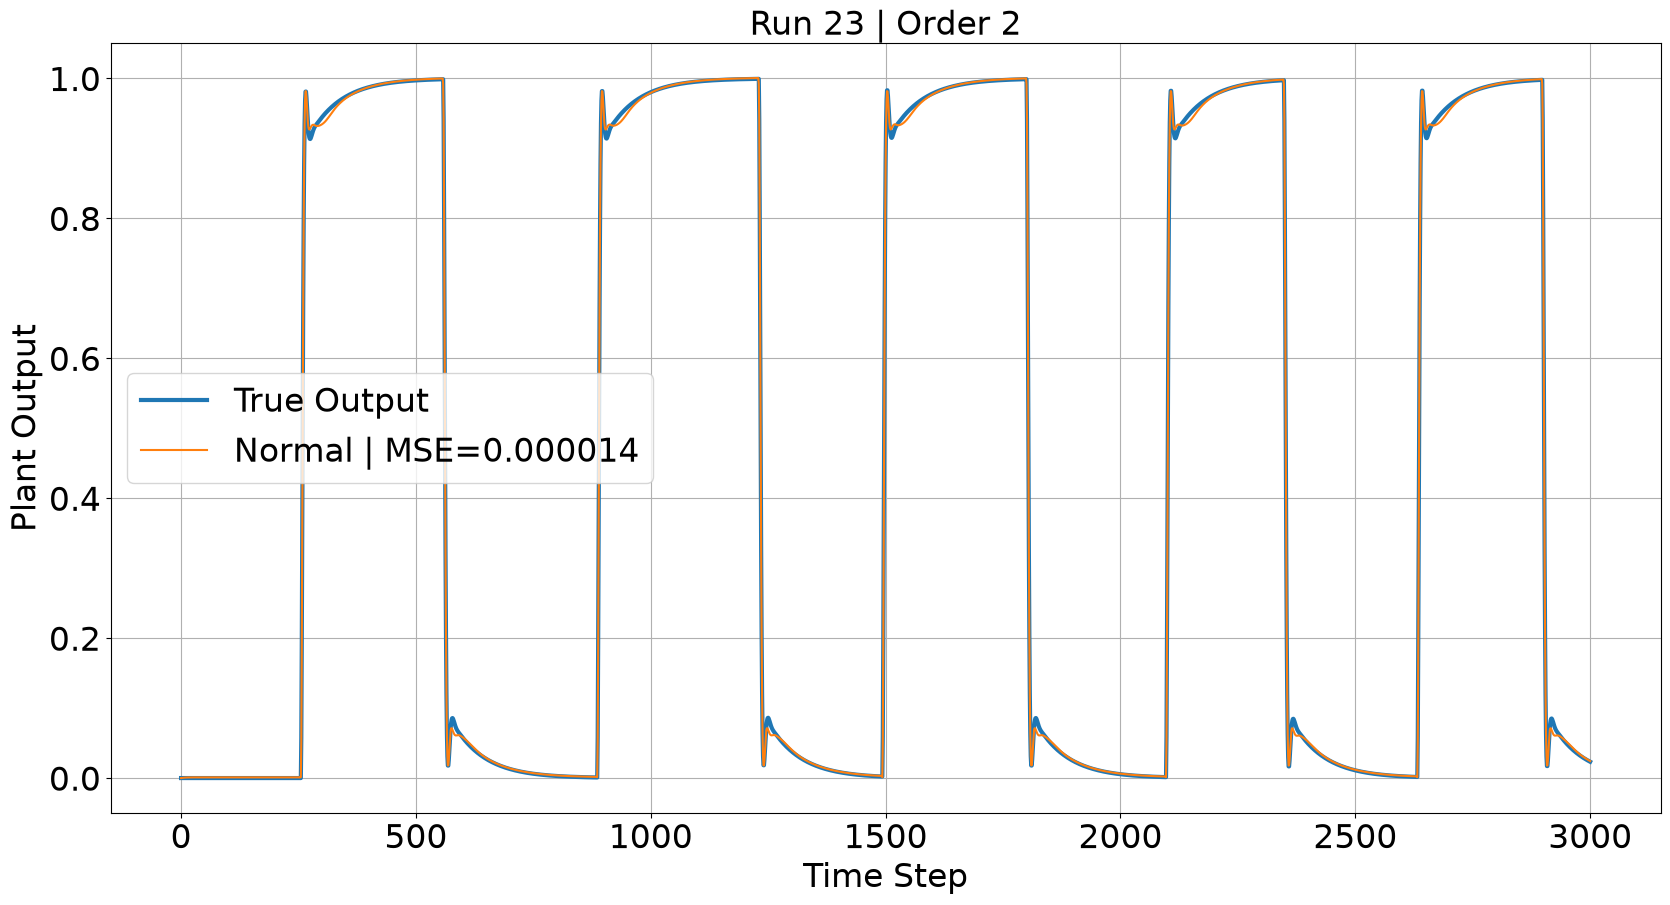

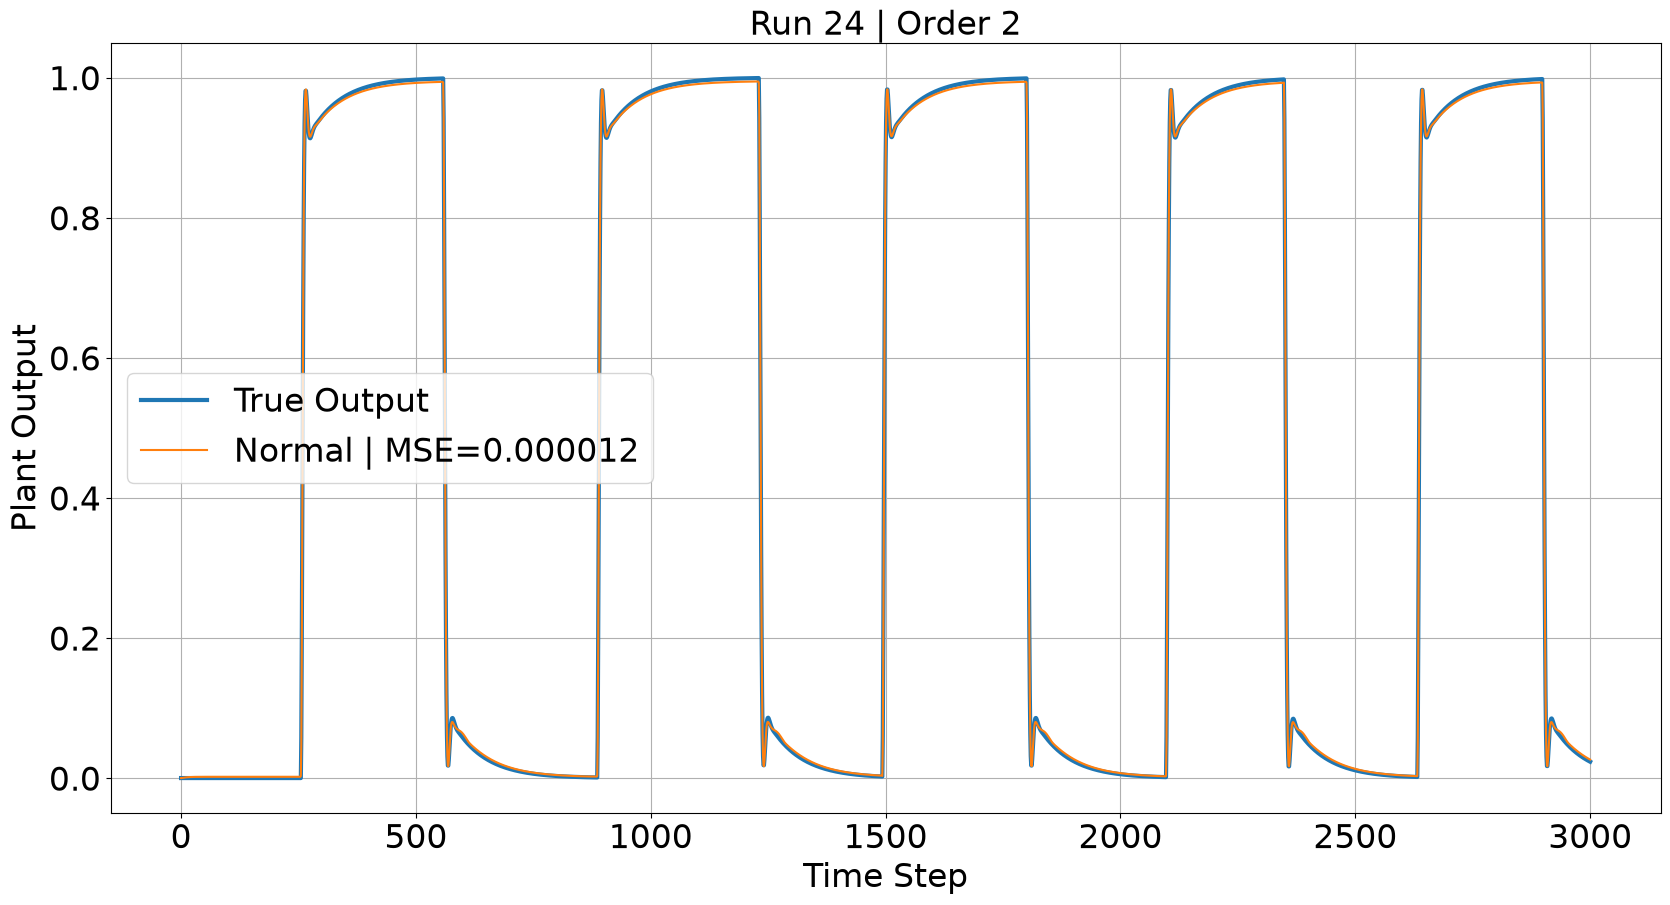

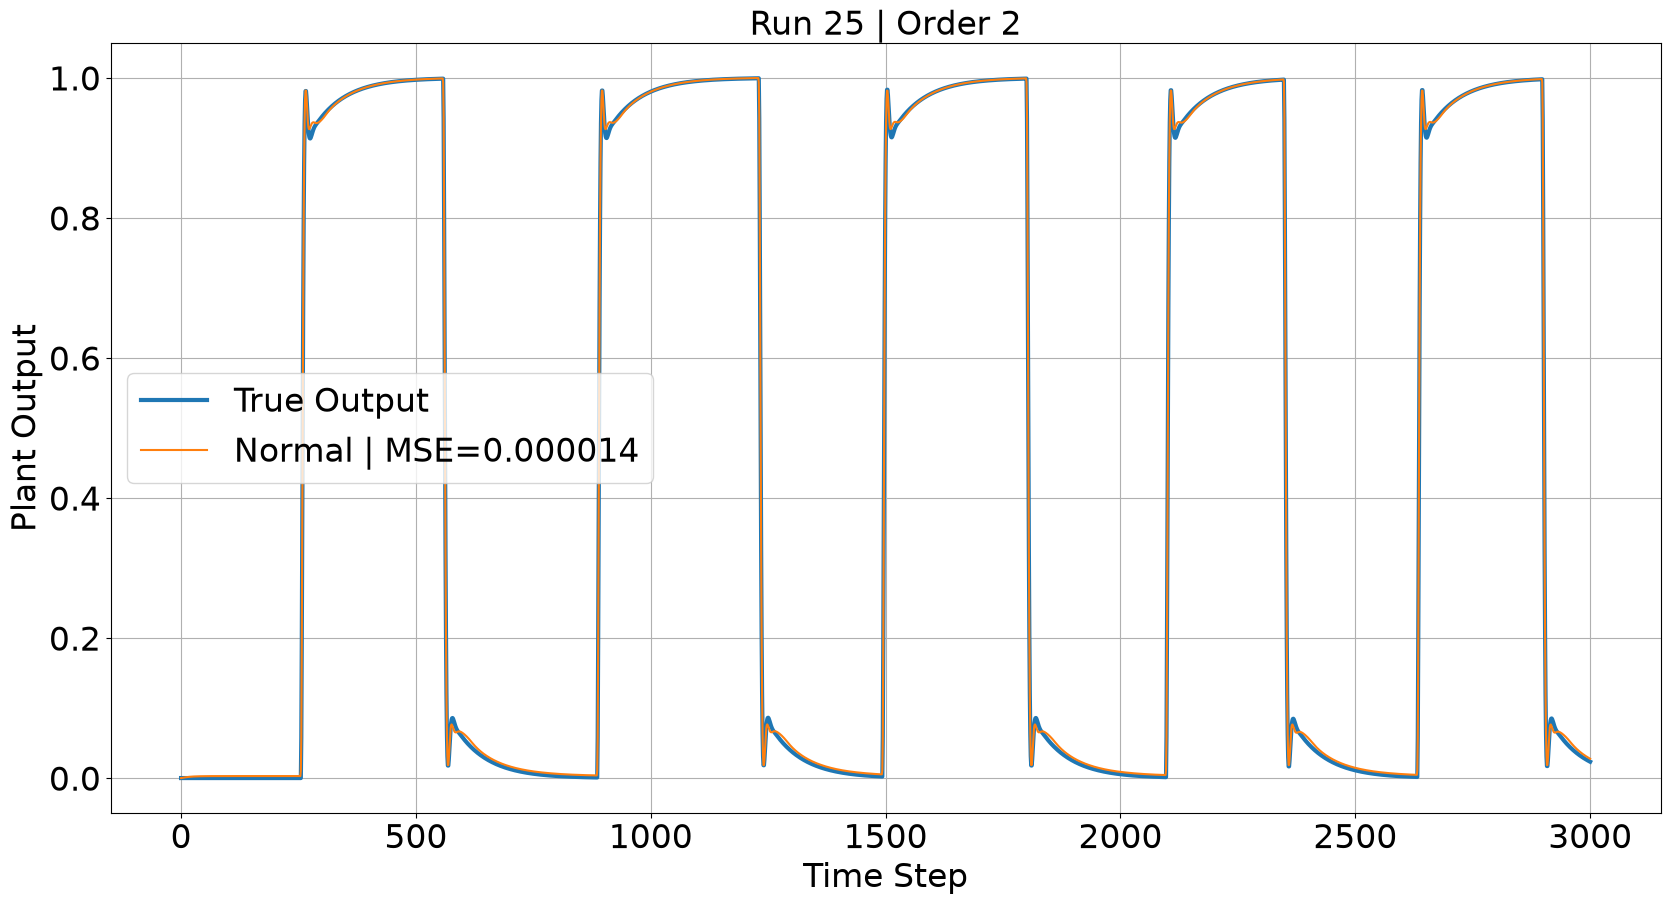

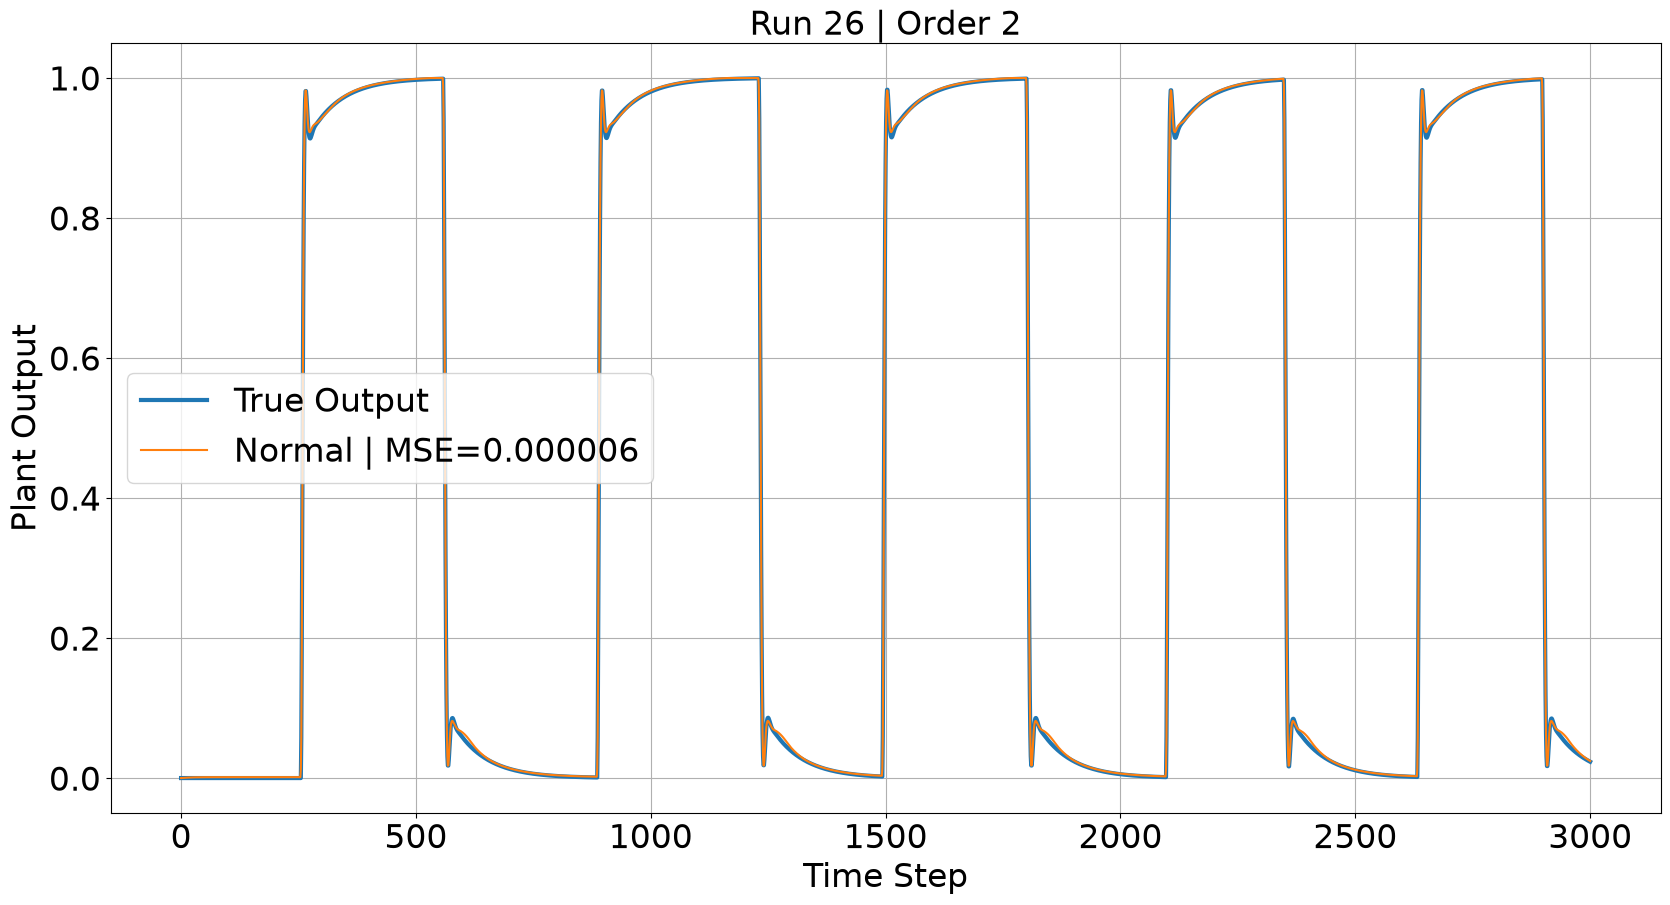

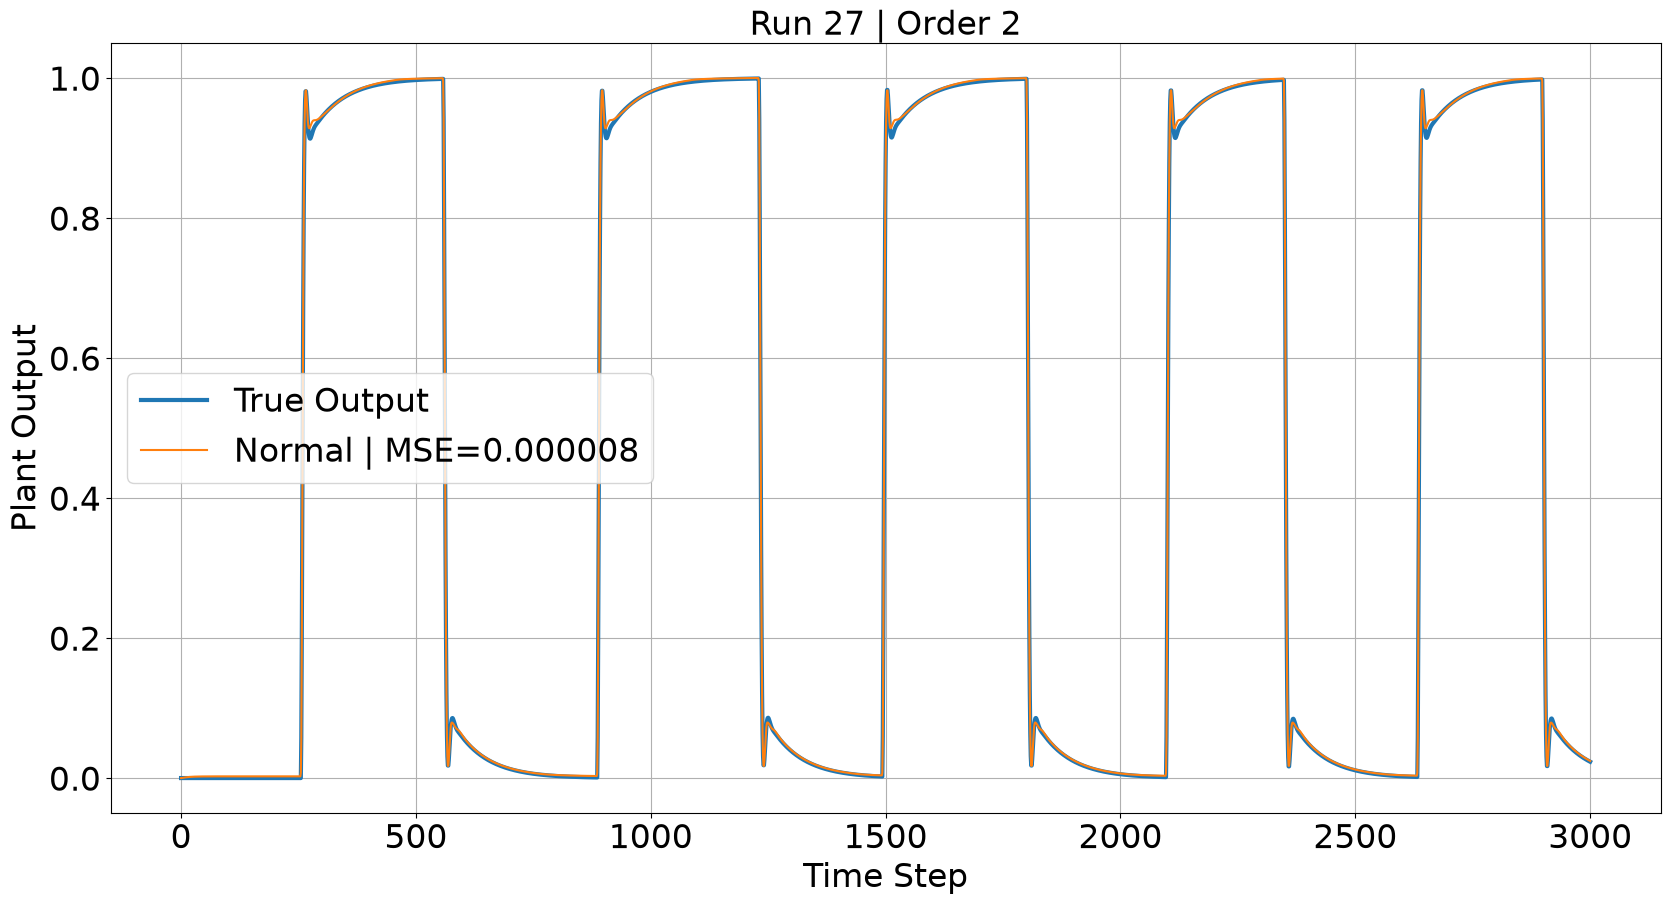

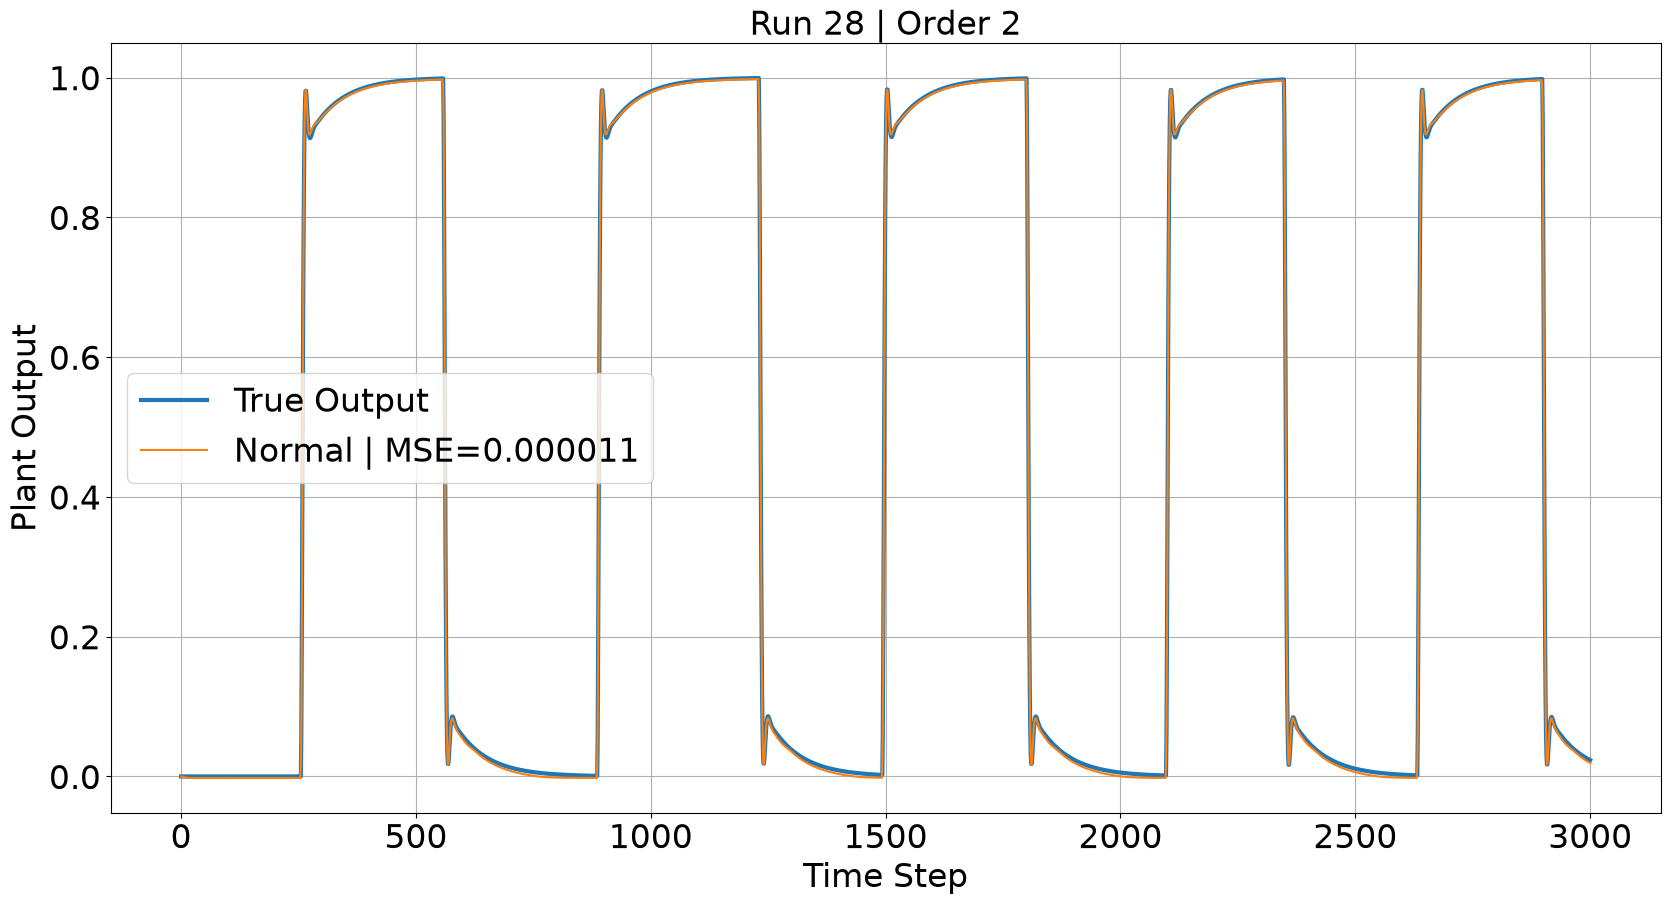

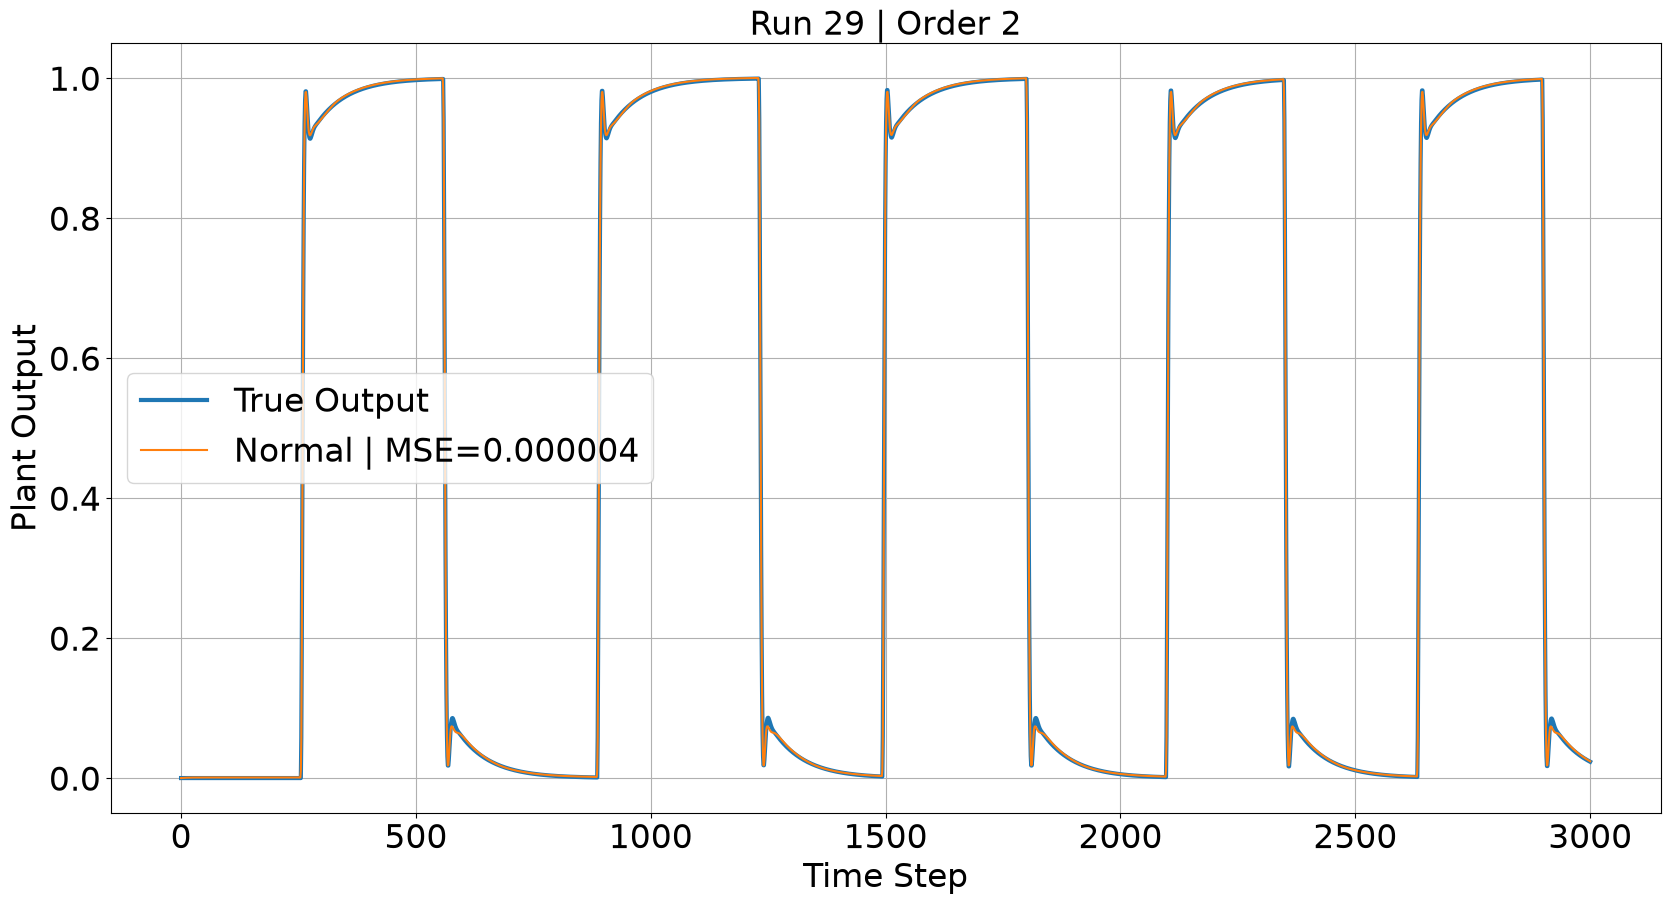

In [32]:
order = 2
for run_i in range(num_runs):
    normal_data = experiments[(run_i, order, "normal_model")]
    y_true = normal_data["targets"][:]
    y_pred_normal = normal_data["predictions"][:]
    mse_normal = normal_data["test_metrics"]["mse"]

    plt.figure(figsize=(20,10))
    plt.plot(y_true,label="True Output",linewidth=3)
    plt.plot(y_pred_normal,label=f"Normal | MSE={mse_normal:.6f}")
    plt.title(f"Run {run_i} | Order {order}")
    plt.xlabel("Time Step")
    plt.ylabel("Plant Output")
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.close()